In [ ]:
TASK 1

In [ ]:
print("=" * 70)
print("STEP 0A: PACKAGES")
print("=" * 70)

print("\n[0A] Installing...")

%pip install -q joblib scikit-learn pyarrow

import gc
import json
import os
import sys
import urllib.request
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import tensorflow as tf
from tensorflow import keras

print("\n[0A] Packages ready.")
print(f"[0A] TensorFlow version: {tf.__version__}")

print("\nSTEP 0A DONE")
print("=" * 70)

STEP 0A: PACKAGES

[0A] Installing...

[0A] Packages ready.
[0A] TensorFlow version: 2.20.0

STEP 0A DONE


In [ ]:
print("=" * 70)
print("STEP 0B: MOUNT DRIVE")
print("=" * 70)

print("\n[0B] Mounting Google Drive...")

from google.colab import drive

drive.mount("/content/drive")

print("[0B] Drive mounted.")

DRIVE_ROOT = Path("/content/drive/MyDrive/vayupath")
DATA_DIR = DRIVE_ROOT / "data"
MODEL_DIR = DRIVE_ROOT / "models"

DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("\n[0B] Folders:")
print(f"     DATA_DIR  = {DATA_DIR}")
print(f"     MODEL_DIR = {MODEL_DIR}")

print("\nSTEP 0B DONE")
print("=" * 70)

STEP 0B: MOUNT DRIVE

[0B] Mounting Google Drive...
Mounted at /content/drive
[0B] Drive mounted.

[0B] Folders:
     DATA_DIR  = /content/drive/MyDrive/vayupath/data
     MODEL_DIR = /content/drive/MyDrive/vayupath/models

STEP 0B DONE


In [ ]:
print("=" * 70)
print("STEP 0C: GPU CHECK")
print("=" * 70)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    for g in gpus:
        print(f"[0C] Found GPU: {g}")
    print("[0C] Good — LSTM training can use the free GPU.")
else:
    print("[0C] WARNING: No GPU found.")
    print("     Go to Runtime → Change runtime type → GPU, then re-run.")

print("\nSTEP 0C DONE")
print("=" * 70)

STEP 0C: GPU CHECK
[0C] WARNING: No GPU found.
     Go to Runtime → Change runtime type → GPU, then re-run.

STEP 0C DONE


In [ ]:
print("=" * 70)
print("STEP 1A: DOWNLOAD YEARLY CPCB FILES (DELHI ONLY)")
print("=" * 70)

import urllib.request

# Years for training
YEARS = [2019, 2020, 2021, 2022, 2023]

# Required pollutant columns
RAW_COLS = [
    "Station Name",
    "Timestamp",
    "PM2.5 (µg/m³)",
    "PM10 (µg/m³)",
    "NO2 (µg/m³)",
    "CO (mg/m³)",
    "Ozone (µg/m³)",
]

TMP_DIR = Path("/content/cpcb_tmp")
TMP_DIR.mkdir(parents=True, exist_ok=True)

delhi_year_files = []

for year in YEARS:

    cache = DATA_DIR / f"delhi_pollutants_{year}.parquet"
    delhi_year_files.append(cache)

    if cache.exists():
        print(
            f"\n[1A] {year}: already cached -> {cache.name} "
            f"({cache.stat().st_size / 1e6:.1f} MB)"
        )
        continue

    url = (
        f"https://github.com/Vonter/india-cpcb-aqi/releases/download/"
        f"{year}/cpcb-air-quality-{year}.parquet"
    )

    tmp = TMP_DIR / f"cpcb-air-quality-{year}.parquet"

    print(f"\n[1A] {year}: downloading...")
    print(f"     {url}")

    urllib.request.urlretrieve(url, tmp)

    print(
        f"     downloaded {tmp.stat().st_size / 1e6:.1f} MB"
    )

    print(f"[1A] {year}: reading and filtering to Delhi...")

    year_df = pd.read_parquet(
        tmp,
        columns=["City"] + RAW_COLS
    )

    delhi = year_df[
        year_df["City"]
        .astype(str)
        .str.strip()
        .str.lower()
        == "delhi"
    ].copy()

    delhi = delhi.drop(columns=["City"])

    delhi.to_parquet(cache, index=False)

    print(
        f"[1A] {year}: saved {len(delhi):,} Delhi rows -> "
        f"{cache.name} "
        f"({cache.stat().st_size / 1e6:.1f} MB)"
    )

    del year_df, delhi

    tmp.unlink(missing_ok=True)

    gc.collect()


print("\n[1A] Delhi cache files ready:")

for path in delhi_year_files:
    print(
        f"     {path.name:32s} "
        f"{path.stat().st_size / 1e6:6.1f} MB"
    )


print("\n[1A] First 5 records from each Delhi file:")

for path in delhi_year_files:

    sample = pd.read_parquet(path)

    print(
        f"\n----- {path.name} "
        f"({len(sample):,} rows) -----"
    )

    display(sample.head(5))

    del sample

gc.collect()

print("\nSTEP 1A DONE")
print("=" * 70)

STEP 1A: DOWNLOAD YEARLY CPCB FILES (DELHI ONLY)

[1A] 2019: downloading...
     https://github.com/Vonter/india-cpcb-aqi/releases/download/2019/cpcb-air-quality-2019.parquet
     downloaded 282.6 MB
[1A] 2019: reading and filtering to Delhi...
[1A] 2019: saved 1,363,514 Delhi rows -> delhi_pollutants_2019.parquet (12.6 MB)

[1A] 2020: downloading...
     https://github.com/Vonter/india-cpcb-aqi/releases/download/2020/cpcb-air-quality-2020.parquet
     downloaded 335.1 MB
[1A] 2020: reading and filtering to Delhi...
[1A] 2020: saved 1,367,306 Delhi rows -> delhi_pollutants_2020.parquet (12.4 MB)

[1A] 2021: downloading...
     https://github.com/Vonter/india-cpcb-aqi/releases/download/2021/cpcb-air-quality-2021.parquet
     downloaded 405.7 MB
[1A] 2021: reading and filtering to Delhi...
[1A] 2021: saved 1,363,334 Delhi rows -> delhi_pollutants_2021.parquet (12.7 MB)

[1A] 2022: downloading...
     https://github.com/Vonter/india-cpcb-aqi/releases/download/2022/cpcb-air-quality-2022.pa

,Station Name,Timestamp,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),CO (mg/m³),Ozone (µg/m³)
0,"Alipur, Delhi - DPCC",2019-01-01 00:00:00+00:00,338.0,512.0,145.1,3.8,1.2
1,"Alipur, Delhi - DPCC",2019-01-01 00:15:00+00:00,338.0,512.0,165.1,4.8,1.8
2,"Alipur, Delhi - DPCC",2019-01-01 00:30:00+00:00,385.0,539.0,170.0,3.6,1.3
3,"Alipur, Delhi - DPCC",2019-01-01 00:45:00+00:00,385.0,539.0,147.4,3.3,NaN
4,"Alipur, Delhi - DPCC",2019-01-01 01:00:00+00:00,385.0,539.0,146.6,2.6,NaN



----- delhi_pollutants_2020.parquet (1,367,306 rows) -----


,Station Name,Timestamp,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),CO (mg/m³),Ozone (µg/m³)
0,"Alipur, Delhi - DPCC",2020-01-01 00:00:00+00:00,279.0,344.0,62.1,2.0,1.8
1,"Alipur, Delhi - DPCC",2020-01-01 00:15:00+00:00,279.0,344.0,61.4,2.0,1.5
2,"Alipur, Delhi - DPCC",2020-01-01 00:30:00+00:00,261.0,312.0,NaN,2.0,2.0
3,"Alipur, Delhi - DPCC",2020-01-01 00:45:00+00:00,261.0,312.0,59.1,1.9,NaN
4,"Alipur, Delhi - DPCC",2020-01-01 01:00:00+00:00,261.0,312.0,55.4,1.9,NaN



----- delhi_pollutants_2021.parquet (1,363,334 rows) -----


...


----- delhi_pollutants_2022.parquet (1,364,216 rows) -----


,Station Name,Timestamp,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),CO (mg/m³),Ozone (µg/m³)
0,"Alipur, Delhi - DPCC",2022-01-01 00:00:00+00:00,217.0,337.0,59.7,1.6,2.6
1,"Alipur, Delhi - DPCC",2022-01-01 00:15:00+00:00,217.0,337.0,56.3,1.6,2.4
2,"Alipur, Delhi - DPCC",2022-01-01 00:30:00+00:00,217.0,337.0,51.5,1.6,2.6
3,"Alipur, Delhi - DPCC",2022-01-01 00:45:00+00:00,227.0,360.0,48.3,1.7,NaN
4,"Alipur, Delhi - DPCC",2022-01-01 01:00:00+00:00,227.0,360.0,NaN,NaN,2.5



----- delhi_pollutants_2023.parquet (1,362,463 rows) -----


,Station Name,Timestamp,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),CO (mg/m³),Ozone (µg/m³)
0,"Alipur, Delhi - DPCC",2023-01-01 00:00:00+00:00,134.0,NaN,31.9,0.9,3.3
1,"Alipur, Delhi - DPCC",2023-01-01 00:15:00+00:00,134.0,174.0,30.9,0.9,3.3
2,"Alipur, Delhi - DPCC",2023-01-01 00:30:00+00:00,134.0,174.0,29.7,0.9,4.8
3,"Alipur, Delhi - DPCC",2023-01-01 00:45:00+00:00,134.0,174.0,27.2,0.8,6.5
4,"Alipur, Delhi - DPCC",2023-01-01 01:00:00+00:00,112.0,138.0,25.7,0.8,NaN



STEP 1A DONE


In [ ]:
print("=" * 70)
print("STEP 1B: COMBINE DELHI YEARS")
print("=" * 70)

RENAME = {
    "Station Name": "station",
    "Timestamp": "timestamp",
    "PM2.5 (µg/m³)": "pm25",
    "PM10 (µg/m³)": "pm10",
    "NO2 (µg/m³)": "no2",
    "CO (mg/m³)": "co",
    "Ozone (µg/m³)": "o3",
}

POLLUTANT_COLS = ["pm25", "pm10", "no2", "co", "o3"]

parts = []
for path in delhi_year_files:
    part = pd.read_parquet(path).rename(columns=RENAME)
    print(f"[1B] {path.name}: {len(part):,} rows")
    parts.append(part)

df = pd.concat(parts, ignore_index=True)
del parts
gc.collect()

# Timestamps are UTC in the source. Convert to India time so
# "hour of day" matches real Delhi mornings and evenings.
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df["timestamp"] = df["timestamp"].dt.tz_convert("Asia/Kolkata").dt.tz_localize(None)

df = df.sort_values(["station", "timestamp"]).reset_index(drop=True)

print(f"\n[1B] Combined: {len(df):,} rows (still 15-minute resolution)")
print(f"     Stations : {df['station'].nunique()}")
print(f"     Range    : {df['timestamp'].min()}  ->  {df['timestamp'].max()}")
print("\n[1B] Sample:")
display(df.head(3))

print("\nSTEP 1B DONE")
print("=" * 70)

STEP 1B: COMBINE DELHI YEARS
[1B] delhi_pollutants_2019.parquet: 1,363,514 rows
[1B] delhi_pollutants_2020.parquet: 1,367,306 rows
[1B] delhi_pollutants_2021.parquet: 1,363,334 rows
[1B] delhi_pollutants_2022.parquet: 1,364,216 rows
[1B] delhi_pollutants_2023.parquet: 1,362,463 rows

[1B] Combined: 6,820,833 rows (still 15-minute resolution)
     Stations : 39
     Range    : 2019-01-01 05:30:00  ->  2024-01-01 05:15:00

[1B] Sample:


,station,timestamp,pm25,pm10,no2,co,o3
0,"Alipur, Delhi - DPCC",2019-01-01 05:30:00,338.0,512.0,145.1,3.8,1.2
1,"Alipur, Delhi - DPCC",2019-01-01 05:45:00,338.0,512.0,165.1,4.8,1.8
2,"Alipur, Delhi - DPCC",2019-01-01 06:00:00,385.0,539.0,170.0,3.6,1.3



STEP 1B DONE


In [ ]:
print("=" * 70)
print("STEP 1C: AGGREGATE TO HOURLY")
print("=" * 70)

before = len(df)

df["timestamp"] = df["timestamp"].dt.floor("h")

df = (
    df.groupby(
        ["station", "timestamp"],
        as_index=False
    )[POLLUTANT_COLS]
    .mean()
    .sort_values(["station", "timestamp"])
    .reset_index(drop=True)
)

print(
    f"\n[1C] {before:,} fifteen-minute rows  ->  "
    f"{len(df):,} hourly rows"
)

print(f"[1C] Stations: {df['station'].nunique()}")

print("\n[1C] Sample hourly rows:")

display(df.head(5))

print("\nSTEP 1C DONE")
print("=" * 70)

STEP 1C: AGGREGATE TO HOURLY

[1C] 6,820,833 fifteen-minute rows  ->  1,707,496 hourly rows
[1C] Stations: 39

[1C] Sample hourly rows:


,station,timestamp,pm25,pm10,no2,co,o3
0,"Alipur, Delhi - DPCC",2019-01-01 05:00:00,338.0,512.0,155.100,4.300,1.500
1,"Alipur, Delhi - DPCC",2019-01-01 06:00:00,385.0,539.0,152.775,2.975,1.300
2,"Alipur, Delhi - DPCC",2019-01-01 07:00:00,311.0,489.0,137.400,2.400,3.125
3,"Alipur, Delhi - DPCC",2019-01-01 08:00:00,285.0,444.0,119.725,1.750,9.400
4,"Alipur, Delhi - DPCC",2019-01-01 09:00:00,268.0,415.0,109.475,1.800,10.150



STEP 1C DONE


In [ ]:
print("=" * 70)
print("STEP 1D: INSPECT")
print("=" * 70)

print(f"\n[1D] Rows        : {len(df):,}")
print(f"     Stations    : {df['station'].nunique()}")
print(f"     Date range  : {df['timestamp'].min()}  ->  {df['timestamp'].max()}")

print("\n[1D] Missing % per pollutant:")
for col in POLLUTANT_COLS:
    pct = df[col].isna().mean() * 100
    print(f"     {col:6s}  {pct:5.1f}%")

print("\n[1D] Value ranges:")
print(f"     {'col':6s} {'min':>10} {'median':>10} {'max':>10}")
for col in POLLUTANT_COLS:
    s = df[col].dropna()
    print(f"     {col:6s} {s.min():10.1f} {s.median():10.1f} {s.max():10.1f}")

print("\n[1D] Rows per year:")
for year, count in df.groupby(df["timestamp"].dt.year).size().items():
    print(f"     {year}: {count:,}")

print("\n[1D] Stations:")
for name in sorted(df["station"].unique()):
    print(f"     - {name}")

print("\nSTEP 1D DONE")
print("=" * 70)

STEP 1D: INSPECT

[1D] Rows        : 1,707,496
     Stations    : 39
     Date range  : 2019-01-01 05:00:00  ->  2024-01-01 05:00:00

[1D] Missing % per pollutant:
     pm25      9.4%
     pm10     12.1%
     no2       9.8%
     co       10.2%
     o3       10.5%

[1D] Value ranges:
     col           min     median        max
     pm25          0.0       69.2     1000.0
     pm10          0.0      171.0     1000.0
     no2           0.0       28.8      499.8
     co            0.0        1.0       47.8
     o3            0.0       18.2      200.0

[1D] Rows per year:
     2019: 341,030
     2020: 342,389
     2021: 341,248
     2022: 341,492
     2023: 341,103
     2024: 234

[1D] Stations:
     - Alipur, Delhi - DPCC
     - Anand Vihar, Delhi - DPCC
     - Ashok Vihar, Delhi - DPCC
     - Aya Nagar, Delhi - IMD
     - Bawana, Delhi - DPCC
     - Burari Crossing, Delhi - IMD
     - CRRI Mathura Road, Delhi - IMD
     - Chandni Chowk, Delhi - IITM
     - DTU, Delhi - CPCB
     - Dr. Ka

In [ ]:
print("=" * 70)
print("STEP 2A: CLEAN INVALID VALUES")
print("=" * 70)

LIMITS = {
    "pm25": (0, 1000),
    "pm10": (0, 1500),
    "no2": (0, 700),
    "co": (0, 50),
    "o3": (0, 500),
}

print("\n[2A] Cleaning each pollutant...")

for col in POLLUTANT_COLS:

    before_na = int(df[col].isna().sum())

    # Known CPCB error sentinel
    df.loc[df[col] == 999, col] = np.nan

    low, high = LIMITS[col]

    bad = (
        df[col].notna()
        & ~df[col].between(low, high)
    )

    df.loc[bad, col] = np.nan

    after_na = int(df[col].isna().sum())

    print(
        f"     {col:6s}: removed "
        f"{after_na - before_na:,} bad values "
        f"(now {df[col].isna().mean() * 100:4.1f}% blank)"
    )


# Rows without PM2.5 cannot be used for the target later
before = len(df)

df = df[df["pm25"].notna()].copy()

print(
    f"\n[2A] Dropped rows with no PM2.5: "
    f"{before - len(df):,}"
)

print(f"[2A] Rows left: {len(df):,}")

print("\nSTEP 2A DONE")
print("=" * 70)

STEP 2A: CLEAN INVALID VALUES

[2A] Cleaning each pollutant...
     pm25  : removed 0 bad values (now  9.4% blank)
     pm10  : removed 2 bad values (now 12.1% blank)
     no2   : removed 0 bad values (now  9.8% blank)
     co    : removed 0 bad values (now 10.2% blank)
     o3    : removed 0 bad values (now 10.5% blank)

[2A] Dropped rows with no PM2.5: 160,226
[2A] Rows left: 1,547,270

STEP 2A DONE


In [ ]:
print("=" * 70)
print("STEP 2B: STATION COVERAGE")
print("=" * 70)

MIN_COVERAGE = 0.50

date_min = df["timestamp"].min()
date_max = df["timestamp"].max()

total_hours = len(
    pd.date_range(date_min, date_max, freq="h")
)

readings = df.groupby("station")["pm25"].count()
coverage = readings / total_hours

print(f"\n[2B] Date range: {date_min}  ->  {date_max}")
print(f"[2B] Hours in the date range: {total_hours:,}")

print("\n[2B] Coverage per station (share of hours with PM2.5):")

for name, pct in coverage.sort_values(ascending=False).items():
    flag = "keep" if pct >= MIN_COVERAGE else "DROP"

    print(
        f"     {name[:46]:46} "
        f"{pct * 100:5.1f}%   {flag}"
    )

good_stations = sorted(
    coverage[coverage >= MIN_COVERAGE].index
)

df = df[df["station"].isin(good_stations)].copy()

print(
    f"\n[2B] Keeping {len(good_stations)} "
    f"of {len(coverage)} stations."
)

print(f"[2B] Rows now: {len(df):,}")

if len(good_stations) < 5:
    raise RuntimeError(
        "Fewer than 5 stations survived. Check Step 2A."
    )

print("\nSTEP 2B DONE")
print("=" * 70)

STEP 2B: STATION COVERAGE

[2B] Date range: 2019-01-01 05:00:00  ->  2024-01-01 05:00:00
[2B] Hours in the date range: 43,825

[2B] Coverage per station (share of hours with PM2.5):
     Major Dhyan Chand National Stadium, Delhi - DP  98.0%   keep
     Dwarka-Sector 8, Delhi - DPCC                   98.0%   keep
     Rohini, Delhi - DPCC                            97.9%   keep
     Sri Aurobindo Marg, Delhi - DPCC                97.9%   keep
     Okhla Phase-2, Delhi - DPCC                     97.7%   keep
     NSIT Dwarka, Delhi - CPCB                       97.6%   keep
     Nehru Nagar, Delhi - DPCC                       97.4%   keep
     Bawana, Delhi - DPCC                            97.1%   keep
     Shadipur, Delhi - CPCB                          97.0%   keep
     CRRI Mathura Road, Delhi - IMD                  96.8%   keep
     Sonia Vihar, Delhi - DPCC                       96.5%   keep
     Patparganj, Delhi - DPCC                        96.5%   keep
     Jawaharlal Nehru Stad

In [ ]:
print("=" * 70)
print("STEP 2C: COMPLETE HOURLY TIMELINE")
print("=" * 70)

FFILL_LIMIT = 3

all_hours = pd.date_range(
    df["timestamp"].min(),
    df["timestamp"].max(),
    freq="h"
)

full_index = pd.MultiIndex.from_product(
    [good_stations, all_hours],
    names=["station", "timestamp"]
)

print(
    f"\n[2C] {len(good_stations)} stations x "
    f"{len(all_hours):,} hours = "
    f"{len(full_index):,} slots"
)

df = (
    df.set_index(["station", "timestamp"])
      .reindex(full_index)
      .reset_index()
)

print("\n[2C] Forward-filling gaps of up to 3 hours...")

for col in POLLUTANT_COLS:

    before = int(df[col].isna().sum())

    df[col] = (
        df.groupby("station")[col]
          .ffill(limit=FFILL_LIMIT)
    )

    after = int(df[col].isna().sum())

    print(
        f"     {col:6s}: filled {before - after:,} "
        f"| still blank {after:,}"
    )

print(
    f"\n[2C] Records now: {len(df):,} rows "
    f"({df['station'].nunique()} stations x "
    f"{df['timestamp'].nunique():,} hours)"
)

gc.collect()

print("\nSTEP 2C DONE")
print("=" * 70)

STEP 2C: COMPLETE HOURLY TIMELINE

[2C] 36 stations x 43,825 hours = 1,577,700 slots

[2C] Forward-filling gaps of up to 3 hours...
     pm25  : filled 22,777 | still blank 58,571
     pm10  : filled 27,817 | still blank 122,675
     no2   : filled 32,314 | still blank 84,938
     co    : filled 42,364 | still blank 85,881
     o3    : filled 39,018 | still blank 92,089

[2C] Records now: 1,577,700 rows (36 stations x 43,825 hours)

STEP 2C DONE


In [ ]:
print("=" * 70)
print("STEP 2D: COMPUTE CPCB AQI")
print("=" * 70)


def sub_index_array(values, breakpoints):
    """
    Map pollutant readings onto the 0-500 AQI scale.
    """

    values = np.asarray(values, dtype=np.float64)

    out = np.full(
        values.shape,
        np.nan,
        dtype=np.float64
    )

    valid = np.isfinite(values) & (values >= 0)

    for c_lo, c_hi, a_lo, a_hi in breakpoints:

        mask = (
            valid
            & np.isnan(out)
            & (values >= c_lo)
            & (values <= c_hi)
        )

        out[mask] = (
            a_lo
            + (a_hi - a_lo)
            * (values[mask] - c_lo)
            / (c_hi - c_lo)
        )

    top = breakpoints[-1][1]

    above = valid & (values > top)

    out[above] = 500.0

    return out


# CPCB breakpoints

BP_PM25 = [
    (0, 30, 0, 50),
    (30, 60, 51, 100),
    (60, 90, 101, 200),
    (90, 120, 201, 300),
    (120, 250, 301, 400),
    (250, 380, 401, 500),
]

BP_PM10 = [
    (0, 50, 0, 50),
    (50, 100, 51, 100),
    (100, 250, 101, 200),
    (250, 350, 201, 300),
    (350, 430, 301, 400),
    (430, 500, 401, 500),
]

BP_NO2 = [
    (0, 40, 0, 50),
    (40, 80, 51, 100),
    (80, 180, 101, 200),
    (180, 280, 201, 300),
    (280, 400, 301, 400),
    (400, 1000, 401, 500),
]

BP_CO = [
    (0, 1.0, 0, 50),
    (1.0, 2.0, 51, 100),
    (2.0, 10.0, 101, 200),
    (10.0, 17.0, 201, 300),
    (17.0, 34.0, 301, 400),
    (34.0, 50.0, 401, 500),
]

BP_O3 = [
    (0, 50, 0, 50),
    (50, 100, 51, 100),
    (100, 168, 101, 200),
    (168, 208, 201, 300),
    (208, 748, 301, 400),
    (748, 1000, 401, 500),
]


print("\n[2D] Computing sub-indices...")

si_pm25 = sub_index_array(df["pm25"], BP_PM25)
si_pm10 = sub_index_array(df["pm10"], BP_PM10)
si_no2 = sub_index_array(df["no2"], BP_NO2)
si_co = sub_index_array(df["co"], BP_CO)
si_o3 = sub_index_array(df["o3"], BP_O3)


# Worst sub-index becomes the AQI

df["aqi"] = np.nanmax(
    np.column_stack([
        si_pm25,
        si_pm10,
        si_no2,
        si_co,
        si_o3
    ]),
    axis=1
)

df.loc[np.isnan(si_pm25), "aqi"] = np.nan

df["aqi"] = df["aqi"].clip(upper=500)


print(
    f"[2D] Rows with AQI : "
    f"{df['aqi'].notna().sum():,} / {len(df):,}"
)

print(f"     unique values : {df['aqi'].nunique():,}")

print(
    f"     mean / std    : "
    f"{df['aqi'].mean():.1f} / "
    f"{df['aqi'].std():.1f}"
)

print(
    f"     min / max     : "
    f"{df['aqi'].min():.1f} / "
    f"{df['aqi'].max():.1f}"
)


print("\n[2D] AQI mean by year:")

for year, g in df.dropna(subset=["aqi"]).groupby(
    df["timestamp"].dt.year
):
    print(
        f"     {year}: mean "
        f"{g['aqi'].mean():6.1f}   "
        f"std {g['aqi'].std():6.1f}"
    )


# Save cleaned hourly table

hourly_path = DATA_DIR / "delhi_cpcb_hourly.csv"

save_cols = [
    "station",
    "timestamp"
] + POLLUTANT_COLS + ["aqi"]

df.loc[
    df["aqi"].notna(),
    save_cols
].to_csv(
    hourly_path,
    index=False
)

print(
    f"\n[2D] Saved cleaned table -> "
    f"{hourly_path}"
)


print("\n[2D] Sample rows (first 5 with AQI):")

display(
    df.loc[
        df["aqi"].notna(),
        save_cols
    ].head(5)
)


print("\nSTEP 2D DONE")
print("=" * 70)

STEP 2D: COMPUTE CPCB AQI

[2D] Computing sub-indices...


/tmp/ipykernel_840/1920247395.py:105: RuntimeWarning: All-NaN slice encountered
  df["aqi"] = np.nanmax(


[2D] Rows with AQI : 1,519,129 / 1,577,700
     unique values : 182,391
     mean / std    : 214.6 / 133.1
     min / max     : 1.7 / 500.0

[2D] AQI mean by year:
     2019: mean  223.7   std  134.1
     2020: mean  194.7   std  132.6
     2021: mean  218.1   std  136.4
     2022: mean  220.2   std  128.2
     2023: mean  216.3   std  132.2
     2024: mean  374.7   std   51.3

[2D] Saved cleaned table -> /content/drive/MyDrive/vayupath/data/delhi_cpcb_hourly.csv

[2D] Sample rows (first 5 with AQI):


,station,timestamp,pm25,pm10,no2,co,o3,aqi
0,"Alipur, Delhi - DPCC",2019-01-01 05:00:00,338.0,512.0,155.100,4.300,1.500,500.000000
1,"Alipur, Delhi - DPCC",2019-01-01 06:00:00,385.0,539.0,152.775,2.975,1.300,500.000000
2,"Alipur, Delhi - DPCC",2019-01-01 07:00:00,311.0,489.0,137.400,2.400,3.125,484.442857
3,"Alipur, Delhi - DPCC",2019-01-01 08:00:00,285.0,444.0,119.725,1.750,9.400,427.653846
4,"Alipur, Delhi - DPCC",2019-01-01 09:00:00,268.0,415.0,109.475,1.800,10.150,414.707692



STEP 2D DONE


In [ ]:
print("=" * 70)
print("STEP 2E: SPATIAL VARIATION CHECK")
print("=" * 70)

per_hour = (
    df.dropna(subset=["aqi"])
      .groupby("timestamp")["aqi"]
)

spread = (per_hour.max() - per_hour.min()).mean()
station_std = per_hour.std().mean()

print("\n[2E] Averaged over every hour:")
print(
    f"     gap between dirtiest and cleanest station : "
    f"{spread:.0f} AQI points"
)
print(
    f"     spread across stations (std)              : "
    f"{station_std:.0f} AQI points"
)

example_hour = (
    df.dropna(subset=["aqi"])
      .groupby("timestamp")
      .size()
      .idxmax()
)

snapshot = (
    df[df["timestamp"] == example_hour]
      .dropna(subset=["aqi"])
      .sort_values("aqi", ascending=False)
)

print(
    f"\n[2E] One real hour ({example_hour}) — "
    f"dirtiest and cleanest:"
)

for _, row in pd.concat(
    [snapshot.head(4), snapshot.tail(4)]
).iterrows():
    print(
        f"     {row['station'][:46]:46} "
        f"{row['aqi']:5.0f}"
    )

print("\n[2E] Average AQI per station:")

for name, value in (
    df.groupby("station")["aqi"]
      .mean()
      .sort_values(ascending=False)
      .items()
):
    print(
        f"     {name[:46]:46} "
        f"{value:5.0f}"
    )

if station_std < 5:
    raise RuntimeError(
        "Stations barely differ from each other. "
        "Route optimization needs real spatial variation — "
        "check the data source."
    )

print(
    "\n     OK: stations genuinely differ. "
    "Route comparison is possible."
)

print("\nSTEP 2E DONE")
print("=" * 70)

STEP 2E: SPATIAL VARIATION CHECK

[2E] Averaged over every hour:
     gap between dirtiest and cleanest station : 229 AQI points
     spread across stations (std)              : 52 AQI points

[2E] One real hour (2019-01-01 05:00:00) — dirtiest and cleanest:
     Alipur, Delhi - DPCC                             500
     Anand Vihar, Delhi - DPCC                        500
     Ashok Vihar, Delhi - DPCC                        500
     CRRI Mathura Road, Delhi - IMD                   500
     Narela, Delhi - DPCC                             422
     Sri Aurobindo Marg, Delhi - DPCC                 379
     Aya Nagar, Delhi - IMD                           373
     Najafgarh, Delhi - DPCC                          348

[2E] Average AQI per station:
     Anand Vihar, Delhi - DPCC                        264
     Mundka, Delhi - DPCC                             255
     Bawana, Delhi - DPCC                             244
     Jahangirpuri, Delhi - DPCC                       244
     Wazirpur,

In [ ]:
print("=" * 70)
print("STEP 3A: TIME FEATURES")
print("=" * 70)


def as_circle(values, period):
    """
    Turn a repeating value into sin/cos coordinates on a circle.
    """
    angle = 2 * np.pi * values / period
    return np.sin(angle), np.cos(angle)


ts = df["timestamp"]

df["hour_sin"], df["hour_cos"] = as_circle(
    ts.dt.hour, 24
)

df["dow_sin"], df["dow_cos"] = as_circle(
    ts.dt.dayofweek, 7
)

df["month_sin"], df["month_cos"] = as_circle(
    ts.dt.month - 1, 12
)


TIME_FEATURES = [
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos"
]


print(
    f"\n[3A] Added {len(TIME_FEATURES)} time features: "
    f"{TIME_FEATURES}"
)


print(
    "\n[3A] Check that midnight and 11pm "
    "end up close together:"
)

for hour in (22, 23, 0, 1):
    s, c = as_circle(
        np.array([hour]),
        24
    )

    print(
        f"     {hour:02d}:00  "
        f"sin={s[0]:+.2f}  "
        f"cos={c[0]:+.2f}"
    )


print("\n[3A] Dataset with time features:")
print(df.head())

print(
    f"\n[3A] Shape: "
    f"{df.shape[0]:,} rows × {df.shape[1]} columns"
)


print("\nSTEP 3A DONE")
print("=" * 70)

STEP 3A: TIME FEATURES

[3A] Added 6 time features: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

[3A] Check that midnight and 11pm end up close together:
     22:00  sin=-0.50  cos=+0.87
     23:00  sin=-0.26  cos=+0.97
     00:00  sin=+0.00  cos=+1.00
     01:00  sin=+0.26  cos=+0.97

[3A] Dataset with time features:
                station           timestamp   pm25   pm10      no2     co  \
0  Alipur, Delhi - DPCC 2019-01-01 05:00:00  338.0  512.0  155.100  4.300   
1  Alipur, Delhi - DPCC 2019-01-01 06:00:00  385.0  539.0  152.775  2.975   
2  Alipur, Delhi - DPCC 2019-01-01 07:00:00  311.0  489.0  137.400  2.400   
3  Alipur, Delhi - DPCC 2019-01-01 08:00:00  285.0  444.0  119.725  1.750   
4  Alipur, Delhi - DPCC 2019-01-01 09:00:00  268.0  415.0  109.475  1.800   

       o3         aqi  hour_sin      hour_cos   dow_sin  dow_cos  month_sin  \
0   1.500  500.000000  0.965926  2.588190e-01  0.781831  0.62349        0.0   
1   1.300  500.000000  1.00000

In [ ]:
print("=" * 70)
print("STEP 3B: STATION COLUMNS")
print("=" * 70)

# Safe to re-run: drop old one-hot columns before recreating them
existing_station_cols = [
    c for c in df.columns
    if c.startswith("station_")
]

if existing_station_cols:
    df = df.drop(columns=existing_station_cols)

station_dummies = pd.get_dummies(
    df["station"],
    prefix="station",
    dtype=np.float32
)

STATION_COLS = sorted(station_dummies.columns)

df = pd.concat(
    [df, station_dummies[STATION_COLS]],
    axis=1
)

del station_dummies
gc.collect()

print(f"\n[3B] Created {len(STATION_COLS)} station columns.")

print("\n[3B] First few:")

for col in STATION_COLS[:5]:
    print(f"     {col}")

print(f"     ... and {len(STATION_COLS) - 5} more")

print(
    "\n[3B] One-hot verification "
    "(first 5 rows — each row should have exactly one 1):"
)

flags = df.iloc[:5][STATION_COLS].to_numpy()

for i in range(5):
    active_col = STATION_COLS[int(flags[i].argmax())]

    print(
        f"     {df.iloc[i]['station']}  →  "
        f"{active_col}"
    )

print(
    "\n[3B] Sample columns "
    "(pollutants + time + this row's station flag):"
)

alipur_col = "station_Alipur, Delhi - DPCC"

show_cols = [
    "station",
    "timestamp",
    "pm25",
    "aqi",
    "hour_sin",
    "hour_cos",
    alipur_col
]

print(df[show_cols].head())

print(
    f"\n[3B] Shape: "
    f"{df.shape[0]:,} rows × {df.shape[1]} columns"
)

print("\nSTEP 3B DONE")
print("=" * 70)

STEP 3B: STATION COLUMNS

[3B] Created 36 station columns.

[3B] First few:
     station_Alipur, Delhi - DPCC
     station_Anand Vihar, Delhi - DPCC
     station_Ashok Vihar, Delhi - DPCC
     station_Aya Nagar, Delhi - IMD
     station_Bawana, Delhi - DPCC
     ... and 31 more

[3B] One-hot verification (first 5 rows — each row should have exactly one 1):
     Alipur, Delhi - DPCC  →  station_Alipur, Delhi - DPCC
     Alipur, Delhi - DPCC  →  station_Alipur, Delhi - DPCC
     Alipur, Delhi - DPCC  →  station_Alipur, Delhi - DPCC
     Alipur, Delhi - DPCC  →  station_Alipur, Delhi - DPCC
     Alipur, Delhi - DPCC  →  station_Alipur, Delhi - DPCC

[3B] Sample columns (pollutants + time + this row's station flag):
                station           timestamp   pm25         aqi  hour_sin  \
0  Alipur, Delhi - DPCC 2019-01-01 05:00:00  338.0  500.000000  0.965926   
1  Alipur, Delhi - DPCC 2019-01-01 06:00:00  385.0  500.000000  1.000000   
2  Alipur, Delhi - DPCC 2019-01-01 07:00:00  311.0

In [ ]:
print("=" * 70)
print("STEP 3C: FEATURE LIST")
print("=" * 70)

TARGET_COL = "aqi"

# Past AQI is included on purpose
FEATURE_COLS = (
    POLLUTANT_COLS
    + [TARGET_COL]
    + TIME_FEATURES
    + STATION_COLS
)

print(f"\n[3C] Predicting : {TARGET_COL}")
print(f"[3C] Using      : {len(FEATURE_COLS)} features")

print(
    f"     {len(POLLUTANT_COLS)}  pollutants: "
    f"{POLLUTANT_COLS}"
)

print("     1  past AQI")

print(
    f"     {len(TIME_FEATURES)}  time-of-day / week / year"
)

print(
    f"     {len(STATION_COLS)} station identity"
)

print("\n[3C] Sample of the finished table:")

display(
    df[
        ["station", "timestamp", "aqi"]
        + POLLUTANT_COLS
    ].head(3)
)

missing = [
    c for c in FEATURE_COLS
    if c not in df.columns
]

if missing:
    raise RuntimeError(
        f"These features are not in the table: {missing}"
    )

print("\nSTEP 3C DONE")
print("=" * 70)

STEP 3C: FEATURE LIST

[3C] Predicting : aqi
[3C] Using      : 48 features
     5  pollutants: ['pm25', 'pm10', 'no2', 'co', 'o3']
     1  past AQI
     6  time-of-day / week / year
     36 station identity

[3C] Sample of the finished table:


,station,timestamp,aqi,pm25,pm10,no2,co,o3
0,"Alipur, Delhi - DPCC",2019-01-01 05:00:00,500.000000,338.0,512.0,155.100,4.300,1.500
1,"Alipur, Delhi - DPCC",2019-01-01 06:00:00,500.000000,385.0,539.0,152.775,2.975,1.300
2,"Alipur, Delhi - DPCC",2019-01-01 07:00:00,484.442857,311.0,489.0,137.400,2.400,3.125



STEP 3C DONE


In [ ]:
print("=" * 70)
print("STEP 4A: SETTINGS")
print("=" * 70)

LOOKBACK = 24
HORIZONS = [1, 6, 12, 24]
MAX_HORIZON = max(HORIZONS)
STRIDE = 6
RANDOM_SEED = 42

# Fixing the seeds means re-running gives the same result
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(
    f"\n[4A] One sample = {LOOKBACK} hours in  "
    f"-> {len(HORIZONS)} numbers out"
)

print(f"     history  : {LOOKBACK} hours")
print(f"     predict  : {HORIZONS} hours ahead")
print(f"     stride   : {STRIDE} hours between windows")
print(f"     seed     : {RANDOM_SEED}")

print(
    f"\n[4A] Each window spans "
    f"{LOOKBACK + MAX_HORIZON} hours in total"
)

print(
    f"     ({LOOKBACK} of history plus "
    f"{MAX_HORIZON} to reach the furthest target)."
)

print("\nSTEP 4A DONE")
print("=" * 70)

STEP 4A: SETTINGS

[4A] One sample = 24 hours in  -> 4 numbers out
     history  : 24 hours
     predict  : [1, 6, 12, 24] hours ahead
     stride   : 6 hours between windows
     seed     : 42

[4A] Each window spans 48 hours in total
     (24 of history plus 24 to reach the furthest target).

STEP 4A DONE


In [ ]:
# STEP 4A
LOOKBACK = 24
HORIZONS = [1, 6, 12, 24]
MAX_HORIZON = 24
STRIDE = 6
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("4A DONE")
print("Features:", len(FEATURE_COLS))
print("Stations:", len(STATION_COLS))

4A DONE
Features: 48
Stations: 36


In [ ]:
# ============================================================
# STEP 4B — SPLIT DATES
# ============================================================

import pandas as pd

print("=" * 70)
print("STEP 4B: SPLIT DATES")
print("=" * 70)

# Use timezone-aware timestamps because your df timestamp is UTC
TRAIN_END = pd.Timestamp("2022-12-31 23:59:59", tz="UTC")
VAL_START = pd.Timestamp("2023-01-01", tz="UTC")
VAL_END = pd.Timestamp("2023-06-30 23:59:59", tz="UTC")
TEST_START = pd.Timestamp("2023-07-01", tz="UTC")

data_start = df["timestamp"].min()
data_end = df["timestamp"].max()

def assign_split(when):
    when = pd.Timestamp(when)

    if when <= TRAIN_END:
        return "train"
    elif VAL_START <= when <= VAL_END:
        return "val"
    else:
        return "test"

print(f"\n[4B] Data covers: {data_start} -> {data_end}")

print("\n[4B] Splits:")
print(f"     TRAIN : {data_start.date()} -> {TRAIN_END.date()}")
print(f"     VAL   : {VAL_START.date()} -> {VAL_END.date()}")
print(f"     TEST  : {TEST_START.date()} -> {data_end.date()}")

print("\nSTEP 4B DONE")
print("=" * 70)

STEP 4B: SPLIT DATES

[4B] Data covers: 2019-01-01 00:00:00+00:00 -> 2024-01-01 00:00:00+00:00

[4B] Splits:
     TRAIN : 2019-01-01 -> 2022-12-31
     VAL   : 2023-01-01 -> 2023-06-30
     TEST  : 2023-07-01 -> 2024-01-01

STEP 4B DONE


In [ ]:
print("=" * 70)
print("STEP 4C: SCALE FEATURES")
print("=" * 70)

train_rows = df["timestamp"] <= TRAIN_END

complete = df[FEATURE_COLS].notna().all(axis=1)

fit_mask = train_rows & complete

scaler = MinMaxScaler()

scaler.fit(
    df.loc[fit_mask, FEATURE_COLS]
)

print(
    f"\n[4C] Scaler fitted on "
    f"{int(fit_mask.sum()):,} complete training rows."
)


FEATURES_SCALED = np.full(
    (len(df), len(FEATURE_COLS)),
    np.nan,
    dtype=np.float32
)

FEATURES_SCALED[complete.to_numpy()] = (
    scaler.transform(
        df.loc[complete, FEATURE_COLS]
    ).astype(np.float32)
)

gc.collect()


print(
    f"[4C] Scaled array shape: "
    f"{FEATURES_SCALED.shape}"
)

print(
    f"     complete rows scaled : "
    f"{int(complete.sum()):,}"
)

print(
    f"     blank rows left as NaN: "
    f"{int((~complete).sum()):,}"
)


aqi_raw = df.loc[
    complete,
    TARGET_COL
].to_numpy()

aqi_scaled = FEATURES_SCALED[
    complete.to_numpy(),
    FEATURE_COLS.index(TARGET_COL)
]


print(
    "\n[4C] What scaling did to the AQI column "
    "(complete rows only):"
)

print(
    f"     before: "
    f"{aqi_raw.min():7.1f} .. "
    f"{aqi_raw.max():7.1f}"
)

print(
    f"     after : "
    f"{aqi_scaled.min():7.3f} .. "
    f"{aqi_scaled.max():7.3f}"
)


print("\nSTEP 4C DONE")
print("=" * 70)

STEP 4C: SCALE FEATURES

[4C] Scaler fitted on 1,100,530 complete training rows.
[4C] Scaled array shape: (1577700, 48)
     complete rows scaled : 1,388,998
     blank rows left as NaN: 188,702

[4C] What scaling did to the AQI column (complete rows only):
     before:     6.2 ..   500.0
     after :   0.000 ..   1.000

STEP 4C DONE


In [ ]:
print("=" * 70)
print("STEP 4D: DEFINE THE WINDOW BUILDER")
print("=" * 70)

station_of_row = df["station"].to_numpy()
aqi_of_row = df[TARGET_COL].to_numpy(dtype=np.float32)
time_of_row = df["timestamp"].to_numpy()


def build_windows_for_station(name):
    """
    Return (X, y, end_times, last_aqi) for one station.

    X         -- (n_windows, 24, n_features) the history
    y         -- (n_windows, 4) AQI at +1h, +6h, +12h, +24h
    end_times -- when each window ends
    last_aqi  -- AQI at the final history hour
    """

    rows = np.where(station_of_row == name)[0]

    aqi = aqi_of_row[rows]
    times = time_of_row[rows]

    X = []
    y = []
    end_times = []
    last_aqi = []

    last_possible_start = (
        len(rows) - LOOKBACK - MAX_HORIZON
    )

    for start in range(
        0,
        last_possible_start + 1,
        STRIDE
    ):

        end = start + LOOKBACK - 1

        # History features must be complete
        history = FEATURES_SCALED[
            rows[start:end + 1]
        ]

        if np.isnan(history).any():
            continue

        # Future AQI targets must also be real
        targets = np.array(
            [
                aqi[end + h]
                for h in HORIZONS
            ],
            dtype=np.float32
        )

        if np.isnan(targets).any():
            continue

        X.append(history)
        y.append(targets)
        end_times.append(times[end])
        last_aqi.append(aqi[end])

    if not X:
        return None

    return (
        np.stack(X).astype(np.float32),
        np.stack(y),
        np.array(end_times),
        np.array(last_aqi, dtype=np.float32),
    )


print(f"\n[4D] Function ready.")

print(
    f"     Each sample: "
    f"({LOOKBACK}, {len(FEATURE_COLS)})"
    f"  ->  {len(HORIZONS)} AQI values"
)

print("\nSTEP 4D DONE")
print("=" * 70)

STEP 4D: DEFINE THE WINDOW BUILDER

[4D] Function ready.
     Each sample: (24, 48)  ->  4 AQI values

STEP 4D DONE


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import gc

DRIVE_ROOT = Path("/content/drive/MyDrive/vayupath")
DATA_DIR = DRIVE_ROOT / "data"
MODEL_DIR = DRIVE_ROOT / "models"

DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Setup ready.")
print("DATA_DIR :", DATA_DIR)
print("MODEL_DIR:", MODEL_DIR)

Setup ready.
DATA_DIR : /content/drive/MyDrive/vayupath/data
MODEL_DIR: /content/drive/MyDrive/vayupath/models


In [ ]:
print("=" * 70)
print("STEP 1A: DOWNLOAD YEARLY CPCB FILES (DELHI ONLY)")
print("=" * 70)

import urllib.request

YEARS = [2019, 2020, 2021, 2022, 2023]

RAW_COLS = [
    "Station Name",
    "Timestamp",
    "PM2.5 (µg/m³)",
    "PM10 (µg/m³)",
    "NO2 (µg/m³)",
    "CO (mg/m³)",
    "Ozone (µg/m³)",
]

TMP_DIR = Path("/content/cpcb_tmp")
TMP_DIR.mkdir(parents=True, exist_ok=True)

delhi_year_files = []

for year in YEARS:

    cache = DATA_DIR / f"delhi_pollutants_{year}.parquet"
    delhi_year_files.append(cache)

    if cache.exists():
        print(
            f"\n[1A] {year}: already cached -> "
            f"{cache.name} "
            f"({cache.stat().st_size / 1e6:.1f} MB)"
        )
        continue

    url = (
        f"https://github.com/Vonter/india-cpcb-aqi/releases/download/"
        f"{year}/cpcb-air-quality-{year}.parquet"
    )

    tmp = TMP_DIR / f"cpcb-air-quality-{year}.parquet"

    print(f"\n[1A] {year}: downloading...")
    urllib.request.urlretrieve(url, tmp)

    print(f"[1A] {year}: reading and filtering to Delhi...")

    year_df = pd.read_parquet(
        tmp,
        columns=["City"] + RAW_COLS
    )

    delhi = year_df[
        year_df["City"].astype(str).str.strip().str.lower() == "delhi"
    ].copy()

    delhi = delhi.drop(columns=["City"])
    delhi.to_parquet(cache, index=False)

    print(
        f"[1A] {year}: saved {len(delhi):,} Delhi rows "
        f"-> {cache.name}"
    )

    del year_df, delhi
    tmp.unlink(missing_ok=True)
    gc.collect()


print("\n[1A] Delhi cache files ready:")

for path in delhi_year_files:
    print(
        f"     {path.name:32s} "
        f"{path.stat().st_size / 1e6:6.1f} MB"
    )

print("\nSTEP 1A DONE")
print("=" * 70)

STEP 1A: DOWNLOAD YEARLY CPCB FILES (DELHI ONLY)

[1A] 2019: downloading...
[1A] 2019: reading and filtering to Delhi...
[1A] 2019: saved 1,363,514 Delhi rows -> delhi_pollutants_2019.parquet

[1A] 2020: downloading...
[1A] 2020: reading and filtering to Delhi...
[1A] 2020: saved 1,367,306 Delhi rows -> delhi_pollutants_2020.parquet

[1A] 2021: downloading...
[1A] 2021: reading and filtering to Delhi...
[1A] 2021: saved 1,363,334 Delhi rows -> delhi_pollutants_2021.parquet

[1A] 2022: downloading...
[1A] 2022: reading and filtering to Delhi...
[1A] 2022: saved 1,364,216 Delhi rows -> delhi_pollutants_2022.parquet

[1A] 2023: downloading...
[1A] 2023: reading and filtering to Delhi...
[1A] 2023: saved 1,362,463 Delhi rows -> delhi_pollutants_2023.parquet

[1A] Delhi cache files ready:
     delhi_pollutants_2019.parquet      12.6 MB
     delhi_pollutants_2020.parquet      12.4 MB
     delhi_pollutants_2021.parquet      12.7 MB
     delhi_pollutants_2022.parquet      13.0 MB
     delhi_po

In [ ]:
print("=" * 70)
print("STEP 1B: COMBINE DELHI YEARS")
print("=" * 70)

RENAME = {
    "Station Name": "station",
    "Timestamp": "timestamp",
    "PM2.5 (µg/m³)": "pm25",
    "PM10 (µg/m³)": "pm10",
    "NO2 (µg/m³)": "no2",
    "CO (mg/m³)": "co",
    "Ozone (µg/m³)": "o3",
}

POLLUTANT_COLS = [
    "pm25",
    "pm10",
    "no2",
    "co",
    "o3"
]

parts = []

for path in delhi_year_files:
    part = pd.read_parquet(path).rename(columns=RENAME)
    print(f"[1B] {path.name}: {len(part):,} rows")
    parts.append(part)

df = pd.concat(parts, ignore_index=True)

del parts
gc.collect()

df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    utc=True
)

df["timestamp"] = (
    df["timestamp"]
    .dt.tz_convert("Asia/Kolkata")
    .dt.tz_localize(None)
)

df = (
    df.sort_values(["station", "timestamp"])
      .reset_index(drop=True)
)

print(
    f"\n[1B] Combined: {len(df):,} rows "
    "(still 15-minute resolution)"
)

print(f"     Stations : {df['station'].nunique()}")

print(
    f"     Range    : "
    f"{df['timestamp'].min()}  ->  "
    f"{df['timestamp'].max()}"
)

print("\n[1B] Sample:")
display(df.head(3))

print("\nSTEP 1B DONE")
print("=" * 70)

STEP 1B: COMBINE DELHI YEARS
[1B] delhi_pollutants_2019.parquet: 1,363,514 rows
[1B] delhi_pollutants_2020.parquet: 1,367,306 rows
[1B] delhi_pollutants_2021.parquet: 1,363,334 rows
[1B] delhi_pollutants_2022.parquet: 1,364,216 rows
[1B] delhi_pollutants_2023.parquet: 1,362,463 rows

[1B] Combined: 6,820,833 rows (still 15-minute resolution)
     Stations : 39
     Range    : 2019-01-01 05:30:00  ->  2024-01-01 05:15:00

[1B] Sample:


,station,timestamp,pm25,pm10,no2,co,o3
0,"Alipur, Delhi - DPCC",2019-01-01 05:30:00,338.0,512.0,145.1,3.8,1.2
1,"Alipur, Delhi - DPCC",2019-01-01 05:45:00,338.0,512.0,165.1,4.8,1.8
2,"Alipur, Delhi - DPCC",2019-01-01 06:00:00,385.0,539.0,170.0,3.6,1.3



STEP 1B DONE


In [ ]:
print("=" * 70)
print("STEP 1C: AGGREGATE TO HOURLY")
print("=" * 70)

before = len(df)

df["timestamp"] = df["timestamp"].dt.floor("h")

df = (
    df.groupby(
        ["station", "timestamp"],
        as_index=False
    )[POLLUTANT_COLS]
    .mean()
    .sort_values(["station", "timestamp"])
    .reset_index(drop=True)
)

print(
    f"\n[1C] {before:,} fifteen-minute rows -> "
    f"{len(df):,} hourly rows"
)

print(f"[1C] Stations: {df['station'].nunique()}")

print("\n[1C] Sample hourly rows:")
display(df.head(5))

print("\nSTEP 1C DONE")
print("=" * 70)

STEP 1C: AGGREGATE TO HOURLY

[1C] 6,820,833 fifteen-minute rows -> 1,707,496 hourly rows
[1C] Stations: 39

[1C] Sample hourly rows:


,station,timestamp,pm25,pm10,no2,co,o3
0,"Alipur, Delhi - DPCC",2019-01-01 05:00:00,338.0,512.0,155.100,4.300,1.500
1,"Alipur, Delhi - DPCC",2019-01-01 06:00:00,385.0,539.0,152.775,2.975,1.300
2,"Alipur, Delhi - DPCC",2019-01-01 07:00:00,311.0,489.0,137.400,2.400,3.125
3,"Alipur, Delhi - DPCC",2019-01-01 08:00:00,285.0,444.0,119.725,1.750,9.400
4,"Alipur, Delhi - DPCC",2019-01-01 09:00:00,268.0,415.0,109.475,1.800,10.150



STEP 1C DONE


In [ ]:
print("=" * 70)
print("STEP 1D: INSPECT")
print("=" * 70)

print(f"\n[1D] Rows        : {len(df):,}")
print(f"     Stations    : {df['station'].nunique()}")
print(
    f"     Date range  : "
    f"{df['timestamp'].min()} -> {df['timestamp'].max()}"
)

print("\n[1D] Missing % per pollutant:")

for col in POLLUTANT_COLS:
    pct = df[col].isna().mean() * 100
    print(f"     {col:6s}  {pct:5.1f}%")

print("\n[1D] Value ranges:")
print(f"     {'col':6s} {'min':>10} {'median':>10} {'max':>10}")

for col in POLLUTANT_COLS:
    s = df[col].dropna()
    print(
        f"     {col:6s} "
        f"{s.min():10.1f} "
        f"{s.median():10.1f} "
        f"{s.max():10.1f}"
    )

print("\n[1D] Rows per year:")

for year, count in (
    df.groupby(df["timestamp"].dt.year).size().items()
):
    print(f"     {year}: {count:,}")

print("\n[1D] Stations:")

for name in sorted(df["station"].unique()):
    print(f"     - {name}")

print("\nSTEP 1D DONE")
print("=" * 70)

STEP 1D: INSPECT

[1D] Rows        : 1,707,496
     Stations    : 39
     Date range  : 2019-01-01 05:00:00 -> 2024-01-01 05:00:00

[1D] Missing % per pollutant:
     pm25      9.4%
     pm10     12.1%
     no2       9.8%
     co       10.2%
     o3       10.5%

[1D] Value ranges:
     col           min     median        max
     pm25          0.0       69.2     1000.0
     pm10          0.0      171.0     1000.0
     no2           0.0       28.8      499.8
     co            0.0        1.0       47.8
     o3            0.0       18.2      200.0

[1D] Rows per year:
     2019: 341,030
     2020: 342,389
     2021: 341,248
     2022: 341,492
     2023: 341,103
     2024: 234

[1D] Stations:
     - Alipur, Delhi - DPCC
     - Anand Vihar, Delhi - DPCC
     - Ashok Vihar, Delhi - DPCC
     - Aya Nagar, Delhi - IMD
     - Bawana, Delhi - DPCC
     - Burari Crossing, Delhi - IMD
     - CRRI Mathura Road, Delhi - IMD
     - Chandni Chowk, Delhi - IITM
     - DTU, Delhi - CPCB
     - Dr. Karn

In [ ]:
print("=" * 70)
print("STEP 2A: CLEAN INVALID VALUES")
print("=" * 70)

LIMITS = {
    "pm25": (0, 1000),
    "pm10": (0, 1500),
    "no2": (0, 700),
    "co": (0, 50),
    "o3": (0, 500),
}

print("\n[2A] Cleaning each pollutant...")

for col in POLLUTANT_COLS:
    before_na = int(df[col].isna().sum())

    df.loc[df[col] == 999, col] = np.nan

    low, high = LIMITS[col]
    bad = df[col].notna() & ~df[col].between(low, high)

    df.loc[bad, col] = np.nan

    after_na = int(df[col].isna().sum())

    print(
        f"     {col:6s}: removed "
        f"{after_na - before_na:,} bad values "
        f"(now {df[col].isna().mean() * 100:4.1f}% blank)"
    )

before = len(df)
df = df[df["pm25"].notna()].copy()

print(f"\n[2A] Dropped rows with no PM2.5: {before - len(df):,}")
print(f"[2A] Rows left: {len(df):,}")

print("\nSTEP 2A DONE")
print("=" * 70)

STEP 2A: CLEAN INVALID VALUES

[2A] Cleaning each pollutant...
     pm25  : removed 0 bad values (now  9.4% blank)
     pm10  : removed 2 bad values (now 12.1% blank)
     no2   : removed 0 bad values (now  9.8% blank)
     co    : removed 0 bad values (now 10.2% blank)
     o3    : removed 0 bad values (now 10.5% blank)

[2A] Dropped rows with no PM2.5: 160,226
[2A] Rows left: 1,547,270

STEP 2A DONE


In [ ]:
print("=" * 70)
print("STEP 2B: STATION COVERAGE")
print("=" * 70)

MIN_COVERAGE = 0.50

date_min = df["timestamp"].min()
date_max = df["timestamp"].max()

total_hours = len(
    pd.date_range(date_min, date_max, freq="h")
)

readings = df.groupby("station")["pm25"].count()
coverage = readings / total_hours

print(f"\n[2B] Date range: {date_min}  ->  {date_max}")
print(f"[2B] Hours in the date range: {total_hours:,}")

print("\n[2B] Coverage per station:")

for name, pct in coverage.sort_values(ascending=False).items():
    flag = "keep" if pct >= MIN_COVERAGE else "DROP"
    print(
        f"     {name[:46]:46} "
        f"{pct * 100:5.1f}%   {flag}"
    )

good_stations = sorted(
    coverage[coverage >= MIN_COVERAGE].index
)

df = df[df["station"].isin(good_stations)].copy()

print(
    f"\n[2B] Keeping {len(good_stations)} "
    f"of {len(coverage)} stations."
)

print(f"[2B] Rows now: {len(df):,}")

if len(good_stations) < 5:
    raise RuntimeError(
        "Fewer than 5 stations survived. Check Step 2A."
    )

print("\nSTEP 2B DONE")
print("=" * 70)

STEP 2B: STATION COVERAGE

[2B] Date range: 2019-01-01 05:00:00  ->  2024-01-01 05:00:00
[2B] Hours in the date range: 43,825

[2B] Coverage per station:
     Major Dhyan Chand National Stadium, Delhi - DP  98.0%   keep
     Dwarka-Sector 8, Delhi - DPCC                   98.0%   keep
     Rohini, Delhi - DPCC                            97.9%   keep
     Sri Aurobindo Marg, Delhi - DPCC                97.9%   keep
     Okhla Phase-2, Delhi - DPCC                     97.7%   keep
     NSIT Dwarka, Delhi - CPCB                       97.6%   keep
     Nehru Nagar, Delhi - DPCC                       97.4%   keep
     Bawana, Delhi - DPCC                            97.1%   keep
     Shadipur, Delhi - CPCB                          97.0%   keep
     CRRI Mathura Road, Delhi - IMD                  96.8%   keep
     Sonia Vihar, Delhi - DPCC                       96.5%   keep
     Patparganj, Delhi - DPCC                        96.5%   keep
     Jawaharlal Nehru Stadium, Delhi - DPCC          9

In [ ]:
print("=" * 70)
print("STEP 2C: COMPLETE HOURLY TIMELINE")
print("=" * 70)

FFILL_LIMIT = 3

all_hours = pd.date_range(
    df["timestamp"].min(),
    df["timestamp"].max(),
    freq="h"
)

full_index = pd.MultiIndex.from_product(
    [good_stations, all_hours],
    names=["station", "timestamp"]
)

print(
    f"\n[2C] {len(good_stations)} stations x "
    f"{len(all_hours):,} hours "
    f"= {len(full_index):,} slots"
)

df = (
    df.set_index(["station", "timestamp"])
      .reindex(full_index)
      .reset_index()
)

print("\n[2C] Forward-filling gaps of up to 3 hours...")

for col in POLLUTANT_COLS:
    before = int(df[col].isna().sum())

    df[col] = (
        df.groupby("station")[col]
          .ffill(limit=FFILL_LIMIT)
    )

    after = int(df[col].isna().sum())

    print(
        f"     {col:6s}: filled {before - after:,} "
        f"| still blank {after:,}"
    )

print(
    f"\n[2C] Records now: {len(df):,} rows "
    f"({df['station'].nunique()} stations x "
    f"{df['timestamp'].nunique():,} hours)"
)

gc.collect()

print("\nSTEP 2C DONE")
print("=" * 70)

STEP 2C: COMPLETE HOURLY TIMELINE

[2C] 36 stations x 43,825 hours = 1,577,700 slots

[2C] Forward-filling gaps of up to 3 hours...
     pm25  : filled 22,777 | still blank 58,571
     pm10  : filled 27,817 | still blank 122,675
     no2   : filled 32,314 | still blank 84,938
     co    : filled 42,364 | still blank 85,881
     o3    : filled 39,018 | still blank 92,089

[2C] Records now: 1,577,700 rows (36 stations x 43,825 hours)

STEP 2C DONE


In [ ]:
print("=" * 70)
print("STEP 2D: COMPUTE CPCB AQI")
print("=" * 70)


def sub_index_array(values, breakpoints):
    values = np.asarray(values, dtype=np.float64)

    out = np.full(
        values.shape,
        np.nan,
        dtype=np.float64
    )

    valid = np.isfinite(values) & (values >= 0)

    for c_lo, c_hi, a_lo, a_hi in breakpoints:
        mask = (
            valid
            & np.isnan(out)
            & (values >= c_lo)
            & (values <= c_hi)
        )

        out[mask] = (
            a_lo
            + (a_hi - a_lo)
            * (values[mask] - c_lo)
            / (c_hi - c_lo)
        )

    top = breakpoints[-1][1]
    above = valid & (values > top)
    out[above] = 500.0

    return out


BP_PM25 = [
    (0, 30, 0, 50),
    (30, 60, 51, 100),
    (60, 90, 101, 200),
    (90, 120, 201, 300),
    (120, 250, 301, 400),
    (250, 380, 401, 500),
]

BP_PM10 = [
    (0, 50, 0, 50),
    (50, 100, 51, 100),
    (100, 250, 101, 200),
    (250, 350, 201, 300),
    (350, 430, 301, 400),
    (430, 500, 401, 500),
]

BP_NO2 = [
    (0, 40, 0, 50),
    (40, 80, 51, 100),
    (80, 180, 101, 200),
    (180, 280, 201, 300),
    (280, 400, 301, 400),
    (400, 1000, 401, 500),
]

BP_CO = [
    (0, 1.0, 0, 50),
    (1.0, 2.0, 51, 100),
    (2.0, 10.0, 101, 200),
    (10.0, 17.0, 201, 300),
    (17.0, 34.0, 301, 400),
    (34.0, 50.0, 401, 500),
]

BP_O3 = [
    (0, 50, 0, 50),
    (50, 100, 51, 100),
    (100, 168, 101, 200),
    (168, 208, 201, 300),
    (208, 748, 301, 400),
    (748, 1000, 401, 500),
]


print("\n[2D] Computing sub-indices...")

si_pm25 = sub_index_array(df["pm25"], BP_PM25)
si_pm10 = sub_index_array(df["pm10"], BP_PM10)
si_no2 = sub_index_array(df["no2"], BP_NO2)
si_co = sub_index_array(df["co"], BP_CO)
si_o3 = sub_index_array(df["o3"], BP_O3)

df["aqi"] = np.nanmax(
    np.column_stack([
        si_pm25,
        si_pm10,
        si_no2,
        si_co,
        si_o3
    ]),
    axis=1
)

df.loc[np.isnan(si_pm25), "aqi"] = np.nan
df["aqi"] = df["aqi"].clip(upper=500)

print(
    f"[2D] Rows with AQI : "
    f"{df['aqi'].notna().sum():,} / {len(df):,}"
)

print(f"     unique values : {df['aqi'].nunique():,}")

print(
    f"     mean / std    : "
    f"{df['aqi'].mean():.1f} / "
    f"{df['aqi'].std():.1f}"
)

print(
    f"     min / max     : "
    f"{df['aqi'].min():.1f} / "
    f"{df['aqi'].max():.1f}"
)

hourly_path = DATA_DIR / "delhi_cpcb_hourly.csv"

save_cols = [
    "station",
    "timestamp"
] + POLLUTANT_COLS + ["aqi"]

df.loc[
    df["aqi"].notna(),
    save_cols
].to_csv(
    hourly_path,
    index=False
)

print(f"\n[2D] Saved cleaned table -> {hourly_path}")

print("\n[2D] Sample rows:")
display(
    df.loc[
        df["aqi"].notna(),
        save_cols
    ].head(5)
)

print("\nSTEP 2D DONE")
print("=" * 70)

STEP 2D: COMPUTE CPCB AQI

[2D] Computing sub-indices...


/tmp/ipykernel_2033/2202421282.py:93: RuntimeWarning: All-NaN slice encountered
  df["aqi"] = np.nanmax(


[2D] Rows with AQI : 1,519,129 / 1,577,700
     unique values : 182,391
     mean / std    : 214.6 / 133.1
     min / max     : 1.7 / 500.0

[2D] Saved cleaned table -> /content/drive/MyDrive/vayupath/data/delhi_cpcb_hourly.csv

[2D] Sample rows:


,station,timestamp,pm25,pm10,no2,co,o3,aqi
0,"Alipur, Delhi - DPCC",2019-01-01 05:00:00,338.0,512.0,155.100,4.300,1.500,500.000000
1,"Alipur, Delhi - DPCC",2019-01-01 06:00:00,385.0,539.0,152.775,2.975,1.300,500.000000
2,"Alipur, Delhi - DPCC",2019-01-01 07:00:00,311.0,489.0,137.400,2.400,3.125,484.442857
3,"Alipur, Delhi - DPCC",2019-01-01 08:00:00,285.0,444.0,119.725,1.750,9.400,427.653846
4,"Alipur, Delhi - DPCC",2019-01-01 09:00:00,268.0,415.0,109.475,1.800,10.150,414.707692



STEP 2D DONE


In [ ]:
print("=" * 70)
print("STEP 2E: SPATIAL VARIATION CHECK")
print("=" * 70)

per_hour = (
    df.dropna(subset=["aqi"])
      .groupby("timestamp")["aqi"]
)

spread = (per_hour.max() - per_hour.min()).mean()
station_std = per_hour.std().mean()

print("\n[2E] Averaged over every hour:")
print(
    f"     gap between dirtiest and cleanest station : "
    f"{spread:.0f} AQI points"
)
print(
    f"     spread across stations (std)              : "
    f"{station_std:.0f} AQI points"
)

example_hour = (
    df.dropna(subset=["aqi"])
      .groupby("timestamp")
      .size()
      .idxmax()
)

snapshot = (
    df[df["timestamp"] == example_hour]
      .dropna(subset=["aqi"])
      .sort_values("aqi", ascending=False)
)

print(
    f"\n[2E] One real hour ({example_hour}) — "
    f"dirtiest and cleanest:"
)

for _, row in pd.concat(
    [snapshot.head(4), snapshot.tail(4)]
).iterrows():
    print(
        f"     {row['station'][:46]:46} "
        f"{row['aqi']:5.0f}"
    )

print("\n[2E] Average AQI per station:")

for name, value in (
    df.groupby("station")["aqi"]
      .mean()
      .sort_values(ascending=False)
      .items()
):
    print(
        f"     {name[:46]:46} "
        f"{value:5.0f}"
    )

if station_std < 5:
    raise RuntimeError(
        "Stations barely differ from each other. "
        "Route optimization needs real spatial variation."
    )

print(
    "\n     OK: stations genuinely differ. "
    "Route comparison is possible."
)

print("\nSTEP 2E DONE")
print("=" * 70)

STEP 2E: SPATIAL VARIATION CHECK

[2E] Averaged over every hour:
     gap between dirtiest and cleanest station : 229 AQI points
     spread across stations (std)              : 52 AQI points

[2E] One real hour (2019-01-01 05:00:00) — dirtiest and cleanest:
     Alipur, Delhi - DPCC                             500
     Anand Vihar, Delhi - DPCC                        500
     Ashok Vihar, Delhi - DPCC                        500
     CRRI Mathura Road, Delhi - IMD                   500
     Narela, Delhi - DPCC                             422
     Sri Aurobindo Marg, Delhi - DPCC                 379
     Aya Nagar, Delhi - IMD                           373
     Najafgarh, Delhi - DPCC                          348

[2E] Average AQI per station:
     Anand Vihar, Delhi - DPCC                        264
     Mundka, Delhi - DPCC                             255
     Bawana, Delhi - DPCC                             244
     Jahangirpuri, Delhi - DPCC                       244
     Wazirpur,

In [ ]:
print("=" * 70)
print("STEP 3A: TIME FEATURES")
print("=" * 70)


def as_circle(values, period):
    angle = 2 * np.pi * values / period
    return np.sin(angle), np.cos(angle)


ts = df["timestamp"]

df["hour_sin"], df["hour_cos"] = as_circle(
    ts.dt.hour, 24
)

df["dow_sin"], df["dow_cos"] = as_circle(
    ts.dt.dayofweek, 7
)

df["month_sin"], df["month_cos"] = as_circle(
    ts.dt.month - 1, 12
)

TIME_FEATURES = [
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos"
]

print(
    f"\n[3A] Added {len(TIME_FEATURES)} time features: "
    f"{TIME_FEATURES}"
)

for hour in (22, 23, 0, 1):
    s, c = as_circle(np.array([hour]), 24)
    print(
        f"     {hour:02d}:00  "
        f"sin={s[0]:+.2f}  cos={c[0]:+.2f}"
    )

print("\n[3A] Dataset with time features:")
print(df.head())

print(
    f"\n[3A] Shape: "
    f"{df.shape[0]:,} rows × {df.shape[1]} columns"
)

print("\nSTEP 3A DONE")
print("=" * 70)

STEP 3A: TIME FEATURES

[3A] Added 6 time features: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
     22:00  sin=-0.50  cos=+0.87
     23:00  sin=-0.26  cos=+0.97
     00:00  sin=+0.00  cos=+1.00
     01:00  sin=+0.26  cos=+0.97

[3A] Dataset with time features:
                station           timestamp   pm25   pm10      no2     co  \
0  Alipur, Delhi - DPCC 2019-01-01 05:00:00  338.0  512.0  155.100  4.300   
1  Alipur, Delhi - DPCC 2019-01-01 06:00:00  385.0  539.0  152.775  2.975   
2  Alipur, Delhi - DPCC 2019-01-01 07:00:00  311.0  489.0  137.400  2.400   
3  Alipur, Delhi - DPCC 2019-01-01 08:00:00  285.0  444.0  119.725  1.750   
4  Alipur, Delhi - DPCC 2019-01-01 09:00:00  268.0  415.0  109.475  1.800   

       o3         aqi  hour_sin      hour_cos   dow_sin  dow_cos  month_sin  \
0   1.500  500.000000  0.965926  2.588190e-01  0.781831  0.62349        0.0   
1   1.300  500.000000  1.000000  6.123234e-17  0.781831  0.62349        0.0   
2   3.125

In [ ]:
print("=" * 70)
print("STEP 3B: STATION COLUMNS")
print("=" * 70)

existing_station_cols = [
    c for c in df.columns
    if c.startswith("station_")
]

if existing_station_cols:
    df = df.drop(columns=existing_station_cols)

station_dummies = pd.get_dummies(
    df["station"],
    prefix="station",
    dtype=np.float32
)

STATION_COLS = sorted(station_dummies.columns)

df = pd.concat(
    [df, station_dummies[STATION_COLS]],
    axis=1
)

del station_dummies
gc.collect()

print(f"\n[3B] Created {len(STATION_COLS)} station columns.")

print("\n[3B] First few:")
for col in STATION_COLS[:5]:
    print(f"     {col}")

print(f"     ... and {len(STATION_COLS) - 5} more")

print("\n[3B] One-hot verification:")

flags = df.iloc[:5][STATION_COLS].to_numpy()

for i in range(5):
    active_col = STATION_COLS[int(flags[i].argmax())]
    print(
        f"     {df.iloc[i]['station']}  →  {active_col}"
    )

alipur_col = "station_Alipur, Delhi - DPCC"

show_cols = [
    "station",
    "timestamp",
    "pm25",
    "aqi",
    "hour_sin",
    "hour_cos",
    alipur_col
]

print("\n[3B] Sample:")
print(df[show_cols].head())

print(
    f"\n[3B] Shape: "
    f"{df.shape[0]:,} rows × {df.shape[1]} columns"
)

print("\nSTEP 3B DONE")
print("=" * 70)

STEP 3B: STATION COLUMNS

[3B] Created 36 station columns.

[3B] First few:
     station_Alipur, Delhi - DPCC
     station_Anand Vihar, Delhi - DPCC
     station_Ashok Vihar, Delhi - DPCC
     station_Aya Nagar, Delhi - IMD
     station_Bawana, Delhi - DPCC
     ... and 31 more

[3B] One-hot verification:
     Alipur, Delhi - DPCC  →  station_Alipur, Delhi - DPCC
     Alipur, Delhi - DPCC  →  station_Alipur, Delhi - DPCC
     Alipur, Delhi - DPCC  →  station_Alipur, Delhi - DPCC
     Alipur, Delhi - DPCC  →  station_Alipur, Delhi - DPCC
     Alipur, Delhi - DPCC  →  station_Alipur, Delhi - DPCC

[3B] Sample:
                station           timestamp   pm25         aqi  hour_sin  \
0  Alipur, Delhi - DPCC 2019-01-01 05:00:00  338.0  500.000000  0.965926   
1  Alipur, Delhi - DPCC 2019-01-01 06:00:00  385.0  500.000000  1.000000   
2  Alipur, Delhi - DPCC 2019-01-01 07:00:00  311.0  484.442857  0.965926   
3  Alipur, Delhi - DPCC 2019-01-01 08:00:00  285.0  427.653846  0.866025   
4  A

In [ ]:
print("=" * 70)
print("STEP 3C: FEATURE LIST")
print("=" * 70)

TARGET_COL = "aqi"

FEATURE_COLS = (
    POLLUTANT_COLS
    + [TARGET_COL]
    + TIME_FEATURES
    + STATION_COLS
)

print(f"\n[3C] Predicting : {TARGET_COL}")
print(f"[3C] Using      : {len(FEATURE_COLS)} features")
print(f"     {len(POLLUTANT_COLS)} pollutants: {POLLUTANT_COLS}")
print("     1 past AQI")
print(f"     {len(TIME_FEATURES)} time features")
print(f"     {len(STATION_COLS)} station identity")

print("\n[3C] Sample:")
display(
    df[
        ["station", "timestamp", "aqi"]
        + POLLUTANT_COLS
    ].head(3)
)

missing = [
    c for c in FEATURE_COLS
    if c not in df.columns
]

if missing:
    raise RuntimeError(
        f"These features are not in the table: {missing}"
    )

print("\nSTEP 3C DONE")
print("=" * 70)

STEP 3C: FEATURE LIST

[3C] Predicting : aqi
[3C] Using      : 48 features
     5 pollutants: ['pm25', 'pm10', 'no2', 'co', 'o3']
     1 past AQI
     6 time features
     36 station identity

[3C] Sample:


,station,timestamp,aqi,pm25,pm10,no2,co,o3
0,"Alipur, Delhi - DPCC",2019-01-01 05:00:00,500.000000,338.0,512.0,155.100,4.300,1.500
1,"Alipur, Delhi - DPCC",2019-01-01 06:00:00,500.000000,385.0,539.0,152.775,2.975,1.300
2,"Alipur, Delhi - DPCC",2019-01-01 07:00:00,484.442857,311.0,489.0,137.400,2.400,3.125



STEP 3C DONE


In [ ]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

TensorFlow: 2.20.0


In [ ]:
import numpy as np
import tensorflow as tf

print("NumPy:", np.__version__)
print("TensorFlow:", tf.__version__)

NumPy: 2.0.2
TensorFlow: 2.20.0


In [ ]:
print("=" * 70)
print("STEP 4A: SETTINGS")
print("=" * 70)

LOOKBACK = 24          # hours of history the model reads
HORIZONS = [1, 6, 12, 24]   # hours ahead we predict
MAX_HORIZON = max(HORIZONS)
STRIDE = 6             # start a new window every 6 hours
RANDOM_SEED = 42

# Fixing the seeds means re-running gives the same result.
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f"\n[4A] One sample = {LOOKBACK} hours in  ->  {len(HORIZONS)} numbers out")
print(f"     history  : {LOOKBACK} hours")
print(f"     predict  : {HORIZONS} hours ahead")
print(f"     stride   : {STRIDE} hours between windows")
print(f"     seed     : {RANDOM_SEED}")

print(f"\n[4A] Each window spans {LOOKBACK + MAX_HORIZON} hours in total")
print(f"     ({LOOKBACK} of history plus {MAX_HORIZON} to reach the furthest target).")

print("\nSTEP 4A DONE")
print("=" * 70)

STEP 4A: SETTINGS

[4A] One sample = 24 hours in  ->  4 numbers out
     history  : 24 hours
     predict  : [1, 6, 12, 24] hours ahead
     stride   : 6 hours between windows
     seed     : 42

[4A] Each window spans 48 hours in total
     (24 of history plus 24 to reach the furthest target).

STEP 4A DONE


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("TensorFlow:", tf.__version__)

pandas: 2.2.2
numpy: 2.0.2
TensorFlow: 2.20.0


In [ ]:
# ============================================================
# FIX — CREATE THE DATAFRAME (df)
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("FIX: LOADING AIR QUALITY DATA")
print("=" * 70)

# Find CSV files in Google Drive
from pathlib import Path

search_paths = [
    Path("/content/drive/MyDrive"),
    Path("/content")
]

csv_files = []

for base in search_paths:
    if base.exists():
        csv_files.extend(base.rglob("*.csv"))

print(f"\nFound {len(csv_files)} CSV file(s).")

for f in csv_files[:20]:
    print(" -", f)


FIX: LOADING AIR QUALITY DATA

Found 4 CSV file(s).
 - /content/sample_data/california_housing_test.csv
 - /content/sample_data/mnist_train_small.csv
 - /content/sample_data/california_housing_train.csv
 - /content/sample_data/mnist_test.csv


In [ ]:
from pathlib import Path

csv_files = []

for base in [Path("/content/drive/MyDrive"), Path("/content")]:
    if base.exists():
        csv_files.extend(base.rglob("*.csv"))

print(f"Found {len(csv_files)} CSV file(s):\n")

for f in csv_files:
    print(f)

Found 4 CSV file(s):

/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_test.csv


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

csv_files = list(Path("/content/drive/MyDrive").rglob("*.csv"))

print(f"Found {len(csv_files)} CSV file(s):")

for i, file in enumerate(csv_files):
    print(i, ":", file)

Found 3 CSV file(s):
0 : /content/drive/MyDrive/Datasets/delhi_air_quality_2018_2024.csv
1 : /content/drive/MyDrive/Delhi_Filtered/delhi_cpcb_hourly.csv
2 : /content/drive/MyDrive/vayupath/data/delhi_cpcb_hourly.csv


In [ ]:
# ============================================================
# FIX — LOAD DATA INTO df
# ============================================================

import pandas as pd
import numpy as np

DATA_PATH = "/content/drive/MyDrive/Delhi_Filtered/delhi_cpcb_hourly.csv"

df = pd.read_csv(DATA_PATH)

print("=" * 70)
print("DATA LOADED")
print("=" * 70)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nDF CREATED SUCCESSFULLY")
print("=" * 70)

DATA LOADED
Shape: (1709175, 14)

Columns:
['station', 'timestamp', 'pm25', 'pm10', 'no2', 'co', 'o3', 'aqi_pm25', 'aqi_pm10', 'aqi_no2', 'aqi_co', 'aqi_o3', 'aqi', 'year']

First 5 rows:


,station,timestamp,pm25,pm10,no2,co,o3,aqi_pm25,aqi_pm10,aqi_no2,aqi_co,aqi_o3,aqi,year
0,"Alipur, Delhi - DPCC",2019-01-01 00:00:00+00:00,338.0,512.0,145.1,3.8,1.2,435.590361,448.449704,165.1,122.303797,1.2,448.449704,2019
1,"Alipur, Delhi - DPCC",2019-01-01 01:00:00+00:00,385.0,539.0,146.6,2.6,1.2,454.277108,464.266272,166.6,107.265823,1.2,464.266272,2019
2,"Alipur, Delhi - DPCC",2019-01-01 02:00:00+00:00,311.0,489.0,146.6,2.6,2.1,424.855422,434.976331,166.6,107.265823,2.1,434.976331,2019
3,"Alipur, Delhi - DPCC",2019-01-01 03:00:00+00:00,285.0,444.0,120.1,1.7,10.2,414.518072,408.615385,140.1,83.666667,10.2,414.518072,2019
4,"Alipur, Delhi - DPCC",2019-01-01 04:00:00+00:00,268.0,415.0,109.1,1.9,10.0,407.759036,381.202532,129.1,94.555556,10.0,407.759036,2019



Data types:
station       object
timestamp     object
pm25         float64
pm10         float64
no2          float64
co           float64
o3           float64
aqi_pm25     float64
aqi_pm10     float64
aqi_no2      float64
aqi_co       float64
aqi_o3       float64
aqi          float64
year           int64
dtype: object

DF CREATED SUCCESSFULLY


In [ ]:
# ============================================================
# STEP 4B — SPLIT DATES
# ============================================================

print("=" * 70)
print("STEP 4B: SPLIT DATES")
print("=" * 70)

# Make timestamp UTC timezone-aware
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

# Split dates — also UTC
TRAIN_END = pd.Timestamp("2022-12-31 23:59:59", tz="UTC")
VAL_START = pd.Timestamp("2023-01-01", tz="UTC")
VAL_END = pd.Timestamp("2023-06-30 23:59:59", tz="UTC")
TEST_START = pd.Timestamp("2023-07-01", tz="UTC")

data_start = df["timestamp"].min()
data_end = df["timestamp"].max()


def assign_split(when):
    if when <= TRAIN_END:
        return "train"
    elif VAL_START <= when <= VAL_END:
        return "val"
    else:
        return "test"


print(f"\nData covers: {data_start} → {data_end}")

rows_per_split = {
    "train": int((df["timestamp"] <= TRAIN_END).sum()),

    "val": int(
        ((df["timestamp"] >= VAL_START) &
         (df["timestamp"] <= VAL_END)).sum()
    ),

    "test": int(
        (df["timestamp"] >= TEST_START).sum()
    )
}

print("\nRows available:")
for split, count in rows_per_split.items():
    print(f"{split.upper():6}: {count:,}")

# Make sure every split has data
for split, count in rows_per_split.items():
    if count == 0:
        raise RuntimeError(
            f"Split '{split}' has no rows. Check the dates."
        )

print("\nSTEP 4B DONE")
print("=" * 70)

STEP 4B: SPLIT DATES

Data covers: 2019-01-01 00:00:00+00:00 → 2024-01-01 00:00:00+00:00

Rows available:
TRAIN : 1,367,496
VAL   : 169,416
TEST  : 172,263

STEP 4B DONE


In [ ]:
print("Current df shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

print("\nStations:", df["station"].nunique())

print("\nDate range:")
print(df["timestamp"].min())
print(df["timestamp"].max())

Current df shape: (1709175, 14)
Columns:
['station', 'timestamp', 'pm25', 'pm10', 'no2', 'co', 'o3', 'aqi_pm25', 'aqi_pm10', 'aqi_no2', 'aqi_co', 'aqi_o3', 'aqi', 'year']

Stations: 39

Date range:
2019-01-01 00:00:00+00:00
2024-01-01 00:00:00+00:00


In [ ]:
# ============================================================
# STEP 4C — SCALE FEATURES
# ============================================================

import gc
import numpy as np
from sklearn.preprocessing import MinMaxScaler

print("=" * 70)
print("STEP 4C: SCALE FEATURES")
print("=" * 70)

FEATURE_COLS = [
    "pm25",
    "pm10",
    "no2",
    "co",
    "o3",
    "aqi"
]

TARGET_COL = "aqi"

# Check columns
missing_cols = [
    col for col in FEATURE_COLS
    if col not in df.columns
]

if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

# Training rows
train_rows = df["timestamp"] <= TRAIN_END

# Complete feature rows
complete = df[FEATURE_COLS].notna().all(axis=1)

# Fit scaler ONLY on training data
fit_mask = train_rows & complete

scaler = MinMaxScaler()

scaler.fit(
    df.loc[fit_mask, FEATURE_COLS]
)

print(
    f"\n[4C] Scaler fitted on "
    f"{int(fit_mask.sum()):,} complete training rows."
)

# Create scaled array
FEATURES_SCALED = np.full(
    (len(df), len(FEATURE_COLS)),
    np.nan,
    dtype=np.float32
)

FEATURES_SCALED[complete.to_numpy()] = (
    scaler.transform(
        df.loc[complete, FEATURE_COLS]
    ).astype(np.float32)
)

gc.collect()

print(
    f"[4C] Scaled array shape: "
    f"{FEATURES_SCALED.shape}"
)

print(
    f"     complete rows scaled : "
    f"{int(complete.sum()):,}"
)

print(
    f"     blank rows left as NaN: "
    f"{int((~complete).sum()):,}"
)

# AQI scaling check
aqi_raw = df.loc[
    complete,
    TARGET_COL
].to_numpy()

aqi_scaled = FEATURES_SCALED[
    complete.to_numpy(),
    FEATURE_COLS.index(TARGET_COL)
]

print("\n[4C] AQI scaling:")
print(
    f"     before: "
    f"{aqi_raw.min():7.1f} .. "
    f"{aqi_raw.max():7.1f}"
)

print(
    f"     after : "
    f"{aqi_scaled.min():7.3f} .. "
    f"{aqi_scaled.max():7.3f}"
)

print("\nSTEP 4C DONE")
print("=" * 70)

STEP 4C: SCALE FEATURES

[4C] Scaler fitted on 1,114,794 complete training rows.
[4C] Scaled array shape: (1709175, 6)
     complete rows scaled : 1,406,795
     blank rows left as NaN: 302,380

[4C] AQI scaling:
     before:     3.5 ..   500.0
     after :   0.000 ..   1.000

STEP 4C DONE


In [ ]:
print("=" * 70)
print("STEP 4D: DEFINE THE WINDOW BUILDER")
print("=" * 70)

station_of_row = df["station"].to_numpy()
aqi_of_row = df[TARGET_COL].to_numpy(dtype=np.float32)
time_of_row = df["timestamp"].to_numpy()


def build_windows_for_station(name):
    """
    Return (X, y, end_times, last_aqi) for one station.
    """

    rows = np.where(station_of_row == name)[0]

    aqi = aqi_of_row[rows]
    times = time_of_row[rows]

    X = []
    y = []
    end_times = []
    last_aqi = []

    last_possible_start = (
        len(rows) - LOOKBACK - MAX_HORIZON
    )

    for start in range(
        0,
        last_possible_start + 1,
        STRIDE
    ):
        end = start + LOOKBACK - 1

        history = FEATURES_SCALED[
            rows[start:end + 1]
        ]

        if np.isnan(history).any():
            continue

        targets = np.array(
            [aqi[end + h] for h in HORIZONS],
            dtype=np.float32
        )

        if np.isnan(targets).any():
            continue

        X.append(history)
        y.append(targets)
        end_times.append(times[end])
        last_aqi.append(aqi[end])

    if not X:
        return None

    return (
        np.stack(X).astype(np.float32),
        np.stack(y),
        np.array(end_times),
        np.array(last_aqi, dtype=np.float32),
    )


print(
    f"\n[4D] Function ready."
)

print(
    f"     Each sample: "
    f"({LOOKBACK}, {len(FEATURE_COLS)}) "
    f"-> {len(HORIZONS)} AQI values"
)

print("\nSTEP 4D DONE")
print("=" * 70)

STEP 4D: DEFINE THE WINDOW BUILDER

[4D] Function ready.
     Each sample: (24, 6) -> 4 AQI values

STEP 4D DONE


In [ ]:
# ============================================================
# FIX — DEFINE GOOD STATIONS
# ============================================================

print("=" * 70)
print("FIX: GOOD STATIONS")
print("=" * 70)

# Keep stations that have enough complete feature data
station_counts = (
    df.groupby("station")[FEATURE_COLS]
      .apply(lambda x: x.notna().all(axis=1).sum())
)

# Minimum number of complete rows required
MIN_COMPLETE_ROWS = LOOKBACK + MAX_HORIZON + 1

good_stations = sorted(
    station_counts[
        station_counts >= MIN_COMPLETE_ROWS
    ].index.tolist()
)

print(f"\nTotal stations in dataset : {df['station'].nunique()}")
print(f"Good stations             : {len(good_stations)}")
print("\nStations:")

for station in good_stations:
    print(" -", station)

print("\nGOOD_STATIONS READY")
print("=" * 70)

FIX: GOOD STATIONS

Total stations in dataset : 39
Good stations             : 39

Stations:
 - Alipur, Delhi - DPCC
 - Anand Vihar, Delhi - DPCC
 - Ashok Vihar, Delhi - DPCC
 - Aya Nagar, Delhi - IMD
 - Bawana, Delhi - DPCC
 - Burari Crossing, Delhi - IMD
 - CRRI Mathura Road, Delhi - IMD
 - Chandni Chowk, Delhi - IITM
 - DTU, Delhi - CPCB
 - Dr. Karni Singh Shooting Range, Delhi - DPCC
 - Dwarka-Sector 8, Delhi - DPCC 
 - IGI Airport (T3), Delhi - IMD
 - IHBAS, Dilshad Garden, Delhi - CPCB
 - ITO, Delhi - CPCB
 - Jahangirpuri, Delhi - DPCC
 - Jawaharlal Nehru Stadium, Delhi - DPCC
 - Lodhi Road, Delhi - IITM
 - Lodhi Road, Delhi - IMD
 - Major Dhyan Chand National Stadium, Delhi - DPCC
 - Mandir Marg, Delhi - DPCC
 - Mundka, Delhi - DPCC
 - NSIT Dwarka, Delhi - CPCB
 - Najafgarh, Delhi - DPCC
 - Narela, Delhi - DPCC
 - Nehru Nagar, Delhi - DPCC
 - North Campus, DU, Delhi - IMD
 - Okhla Phase-2, Delhi - DPCC
 - Patparganj, Delhi - DPCC
 - Punjabi Bagh, Delhi - DPCC
 - Pusa, Delhi - DP

In [ ]:
# ============================================================
# STEP 4E — BUILD WINDOWS
# ============================================================

import gc
import numpy as np
import pandas as pd

print("=" * 70)
print("STEP 4E: BUILD WINDOWS")
print("=" * 70)

# Create storage for train / validation / test windows
buckets = {
    split: {
        "X": [],
        "y": [],
        "end": [],
        "last": [],
        "station": []
    }
    for split in ("train", "val", "test")
}

print("\n[4E] Station                                  train    val   test")
print("     " + "-" * 60)

# Build windows station by station
for name in good_stations:

    result = build_windows_for_station(name)

    if result is None:
        print(
            f"     {name[:38]:38}  no usable windows"
        )
        continue

    X_station, y_station, ends, lasts = result

    # Determine split from the last timestamp
    labels = np.array([
        assign_split(pd.Timestamp(t))
        for t in ends
    ])

    counts = {}

    for split in ("train", "val", "test"):

        pick = labels == split

        counts[split] = int(pick.sum())

        if counts[split] == 0:
            continue

        buckets[split]["X"].append(
            X_station[pick]
        )

        buckets[split]["y"].append(
            y_station[pick]
        )

        buckets[split]["end"].append(
            ends[pick]
        )

        buckets[split]["last"].append(
            lasts[pick]
        )

        buckets[split]["station"].append(
            np.full(
                counts[split],
                name,
                dtype=object
            )
        )

    print(
        f"     {name[:38]:38} "
        f"{counts['train']:6,} "
        f"{counts['val']:6,} "
        f"{counts['test']:6,}"
    )

    # Free station-level memory
    del X_station
    del y_station
    del ends
    del lasts
    del result

    gc.collect()

print("\nSTEP 4E DONE")
print("=" * 70)

STEP 4E: BUILD WINDOWS

[4E] Station                                  train    val   test
     ------------------------------------------------------------
     Alipur, Delhi - DPCC                    3,851    538    483
     Anand Vihar, Delhi - DPCC               2,670    418    237
     Ashok Vihar, Delhi - DPCC               4,180    495    370
     Aya Nagar, Delhi - IMD                  4,518    563    447
     Bawana, Delhi - DPCC                    4,288    673    597
     Burari Crossing, Delhi - IMD            1,146    365    544
     CRRI Mathura Road, Delhi - IMD          4,753    406    534
     Chandni Chowk, Delhi - IITM             1,245     89      0
     DTU, Delhi - CPCB                       3,550    460    445
     Dr. Karni Singh Shooting Range, Delhi   4,510    650    541
     Dwarka-Sector 8, Delhi - DPCC           4,563    535    539
     IGI Airport (T3), Delhi - IMD           4,355    556    699
     IHBAS, Dilshad Garden, Delhi - CPCB     1,842    353    444

In [ ]:

print("=" * 70)
print("STEP 4F: ASSEMBLE THE SPLITS")
print("=" * 70)


def join(split, key):
    """Concatenate one bucket, then drop the pieces."""
    pieces = buckets[split].pop(key, None)
    if not pieces:
        return None
    joined = np.concatenate(pieces, axis=0)
    pieces.clear()
    gc.collect()
    return joined


X_train, y_train = join("train", "X"), join("train", "y")
X_val, y_val = join("val", "X"), join("val", "y")
X_test, y_test = join("test", "X"), join("test", "y")

end_train, end_val, end_test = join("train", "end"), join("val", "end"), join("test", "end")
station_test = join("test", "station")
last_aqi_val, last_aqi_test = join("val", "last"), join("test", "last")

del buckets
gc.collect()

for name, array in (("train", X_train), ("val", X_val), ("test", X_test)):
    if array is None or len(array) == 0:
        raise RuntimeError(f"Split '{name}' is empty — check the dates in Step 4B.")

total = len(X_train) + len(X_val) + len(X_test)
print("\n[4F] Samples per split:")
for name, array in (("Train", X_train), ("Val", X_val), ("Test", X_test)):
    print(f"     {name:6s} {len(array):8,}  ({100 * len(array) / total:4.1f}%)")

print(f"\n[4F] X_train shape = {X_train.shape}")
print(f"     y_train shape = {y_train.shape}")
print(f"     memory used   = {(X_train.nbytes + X_val.nbytes + X_test.nbytes) / 1e6:,.0f} MB")

print("\n[4F] Dates each split actually covers:")
for name, ends in (("Train", end_train), ("Val", end_val), ("Test", end_test)):
    print(f"     {name:6s} {pd.Timestamp(ends.min()).date()}  ->  {pd.Timestamp(ends.max()).date()}")

print("\n[4F] The +1h target in each split:")
print(f"     {'split':6} {'mean':>8} {'std':>8} {'min':>7} {'max':>7}")
for name, y in (("train", y_train), ("val", y_val), ("test", y_test)):
    col = y[:, 0]
    print(f"     {name:6} {col.mean():8.1f} {col.std():8.1f} {col.min():7.0f} {col.max():7.0f}")

if y_test[:, 0].std() < 5:
    raise RuntimeError("Test targets barely vary — something is wrong with the data.")

print("\nSTEP 4F DONE")
print("=" * 70)

STEP 4F: ASSEMBLE THE SPLITS

[4F] Samples per split:
     Train   144,845  (79.3%)
     Val      19,442  (10.6%)
     Test     18,330  (10.0%)

[4F] X_train shape = (144845, 24, 6)
     y_train shape = (144845, 4)
     memory used   = 105 MB

[4F] Dates each split actually covers:
     Train  2019-01-01  ->  2022-12-31
     Val    2023-01-01  ->  2023-06-30
     Test   2023-07-01  ->  2023-12-30

[4F] The +1h target in each split:
     split      mean      std     min     max
     train     204.2    122.4       4     500
     val       199.0    109.9      20     500
     test      215.3    133.0      10     500

STEP 4F DONE


In [ ]:
print("=" * 70)
print("STEP 5A: SCORING FUNCTION")
print("=" * 70)

def score_model(y_true, y_pred, name):
    """Print a table of accuracy per horizon and return it as a list."""
    results = []

    print(f"\n[{name}]")
    print(
        f"{'Horizon':>9} | {'RMSE':>9} | "
        f"{'MAE':>9} | {'MAPE%':>8} | {'R2':>7}"
    )
    print("-" * 56)

    for i, hours in enumerate(HORIZONS):

        actual = np.asarray(y_true)[:, i].astype(np.float64)
        predicted = np.asarray(y_pred)[:, i].astype(np.float64)

        rmse = float(
            np.sqrt(
                mean_squared_error(actual, predicted)
            )
        )

        mae = float(
            mean_absolute_error(actual, predicted)
        )

        mape = float(
            np.mean(
                np.abs(
                    (actual - predicted) / actual
                )
            ) * 100
        )

        spread = float(np.var(actual))

        r2 = float(
            1.0
            - np.mean((actual - predicted) ** 2)
            / spread
        )

        print(
            f"{'+' + str(hours) + 'h':>9} | "
            f"{rmse:9.3f} | "
            f"{mae:9.3f} | "
            f"{mape:8.2f} | "
            f"{r2:7.3f}"
        )

        results.append({
            "horizon_h": hours,
            "rmse": rmse,
            "mae": mae,
            "mape": mape,
            "r2": r2
        })

    return results


print("\n[5A] score_model() ready.")
print("     Lower RMSE is better. Higher R2 is better.")

print("\nSTEP 5A DONE")
print("=" * 70)

STEP 5A: SCORING FUNCTION

[5A] score_model() ready.
     Lower RMSE is better. Higher R2 is better.

STEP 5A DONE


In [ ]:
print("=" * 70)
print("STEP 5B: PERSISTENCE BASELINE")
print("=" * 70)

n_horizons = len(HORIZONS)

persist_val_pred = np.repeat(
    last_aqi_val[:, None],
    n_horizons,
    axis=1
)

persist_test_pred = np.repeat(
    last_aqi_test[:, None],
    n_horizons,
    axis=1
)

persist_val_metrics = score_model(
    y_val,
    persist_val_pred,
    "Persistence VAL"
)

persist_test_metrics = score_model(
    y_test,
    persist_test_pred,
    "Persistence TEST"
)

print(
    "\n[5B] Notice how the error grows with the horizon: "
    "'nothing changes'"
)

print(
    "     is a fair guess an hour ahead and a poor one a day ahead."
)

print("\nSTEP 5B DONE")
print("=" * 70)

STEP 5B: PERSISTENCE BASELINE

[Persistence VAL]
  Horizon |      RMSE |       MAE |    MAPE% |      R2
--------------------------------------------------------
      +1h |    40.747 |    24.534 |    13.87 |   0.876
      +6h |   106.960 |    76.240 |    44.76 |   0.168
     +12h |   119.175 |    88.609 |    53.67 |  -0.026
     +24h |   101.904 |    72.272 |    45.60 |   0.257

[Persistence TEST]
  Horizon |      RMSE |       MAE |    MAPE% |      R2
--------------------------------------------------------
      +1h |    33.155 |    18.422 |    10.26 |   0.945
      +6h |    88.904 |    58.521 |    32.36 |   0.614
     +12h |    96.019 |    64.838 |    37.13 |   0.550
     +24h |    71.312 |    46.203 |    27.48 |   0.753

[5B] Notice how the error grows with the horizon: 'nothing changes'
     is a fair guess an hour ahead and a poor one a day ahead.

STEP 5B DONE


In [ ]:
from sklearn.linear_model import Ridge
print("=" * 70)
print("STEP 5C: RIDGE BASELINE")
print("=" * 70)

# X is (samples, 24 hours, features) — take just the final hour.
train_last_hour = X_train[:, -1, :]
val_last_hour = X_val[:, -1, :]
test_last_hour = X_test[:, -1, :]

print(f"\n[5C] Ridge input shape: {train_last_hour.shape}  (one hour, not 24)")

ridge = Ridge(alpha=1.0)
ridge.fit(train_last_hour, y_train)
print("[5C] Trained.")

ridge_val_pred = ridge.predict(val_last_hour)
ridge_test_pred = ridge.predict(test_last_hour)

ridge_val_metrics = score_model(y_val, ridge_val_pred, "Ridge VAL")
ridge_test_metrics = score_model(y_test, ridge_test_pred, "Ridge TEST")

print("\n[5C] Prediction spread on TEST (+1h) — a healthy model's")
print("     predictions should vary about as much as reality does:")
print(f"     persistence std = {persist_test_pred[:, 0].std():8.2f}")
print(f"     ridge       std = {ridge_test_pred[:, 0].std():8.2f}")
print(f"     actual      std = {y_test[:, 0].std():8.2f}")

del train_last_hour, val_last_hour, test_last_hour
gc.collect()

print("\nSTEP 5C DONE")
print("=" * 70)

STEP 5C: RIDGE BASELINE

[5C] Ridge input shape: (153199, 48)  (one hour, not 24)
[5C] Trained.

[Ridge VAL]
  Horizon |      RMSE |       MAE |    MAPE% |      R2
--------------------------------------------------------
      +1h |    39.249 |    25.014 |    14.39 |   0.885
      +6h |    88.221 |    67.174 |    44.81 |   0.434
     +12h |    92.805 |    71.897 |    48.43 |   0.378
     +24h |    89.829 |    66.156 |    44.38 |   0.423

[Ridge TEST]
  Horizon |      RMSE |       MAE |    MAPE% |      R2
--------------------------------------------------------
      +1h |    31.681 |    19.410 |    11.36 |   0.950
      +6h |    76.653 |    57.458 |    36.86 |   0.713
     +12h |    79.240 |    60.393 |    39.75 |   0.694
     +24h |    67.596 |    48.198 |    30.80 |   0.778

[5C] Prediction spread on TEST (+1h) — a healthy model's
     predictions should vary about as much as reality does:
     persistence std =   142.74
     ridge       std =   135.49
     actual      std =   141.34

In [ ]:
print("=" * 70)
print("STEP 6A: SCALE THE TARGET")
print("=" * 70)

target_scaler = MinMaxScaler()

target_scaler.fit(y_train)

y_train_scaled = target_scaler.transform(
    y_train
).astype(np.float32)

y_val_scaled = target_scaler.transform(
    y_val
).astype(np.float32)

print(
    f"\n[6A] Target before scaling: "
    f"{y_train.min():7.1f} .. {y_train.max():7.1f}"
)

print(
    f"[6A] Target after scaling : "
    f"{y_train_scaled.min():7.3f} .. "
    f"{y_train_scaled.max():7.3f}"
)

check = target_scaler.inverse_transform(
    y_train_scaled[:100]
)

if not np.allclose(
    check,
    y_train[:100],
    atol=1e-3
):
    raise RuntimeError(
        "Target scaler round-trip failed — "
        "do not trust any metric."
    )

print(
    "[6A] Round-trip check passed "
    "(scaled -> original gives the same numbers)."
)

print("\nSTEP 6A DONE")
print("=" * 70)

STEP 6A: SCALE THE TARGET

[6A] Target before scaling:     6.7 ..   500.0
[6A] Target after scaling :   0.000 ..   1.000
[6A] Round-trip check passed (scaled -> original gives the same numbers).

STEP 6A DONE


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import gc

DATA_DIR = Path("/content/drive/MyDrive/vayupath/data")

YEARS = [2019, 2020, 2021, 2022, 2023]

delhi_year_files = [
    DATA_DIR / f"delhi_pollutants_{year}.parquet"
    for year in YEARS
]

RENAME = {
    "Station Name": "station",
    "Timestamp": "timestamp",
    "PM2.5 (µg/m³)": "pm25",
    "PM10 (µg/m³)": "pm10",
    "NO2 (µg/m³)": "no2",
    "CO (mg/m³)": "co",
    "Ozone (µg/m³)": "o3",
}

POLLUTANT_COLS = ["pm25", "pm10", "no2", "co", "o3"]

for path in delhi_year_files:
    print(path.name, "->", path.exists())

print("\nSetup ready.")

delhi_pollutants_2019.parquet -> False
delhi_pollutants_2020.parquet -> False
delhi_pollutants_2021.parquet -> False
delhi_pollutants_2022.parquet -> False
delhi_pollutants_2023.parquet -> False

Setup ready.


In [ ]:
from pathlib import Path

DRIVE_ROOT = Path("/content/drive/MyDrive/vayupath")
DATA_DIR = DRIVE_ROOT / "data"
MODEL_DIR = DRIVE_ROOT / "models"

DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Setup ready.")
print("DATA_DIR :", DATA_DIR)
print("MODEL_DIR:", MODEL_DIR)

Setup ready.
DATA_DIR : /content/drive/MyDrive/vayupath/data
MODEL_DIR: /content/drive/MyDrive/vayupath/models


In [ ]:
print("=" * 70)
print("STEP 1A: DOWNLOAD YEARLY CPCB FILES (DELHI ONLY)")
print("=" * 70)

import urllib.request
from pathlib import Path
import pandas as pd
import gc

DATA_DIR = Path("/content/drive/MyDrive/vayupath/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

YEARS = [2019, 2020, 2021, 2022, 2023]

RAW_COLS = [
    "Station Name",
    "Timestamp",
    "PM2.5 (µg/m³)",
    "PM10 (µg/m³)",
    "NO2 (µg/m³)",
    "CO (mg/m³)",
    "Ozone (µg/m³)",
]

TMP_DIR = Path("/content/cpcb_tmp")
TMP_DIR.mkdir(parents=True, exist_ok=True)

delhi_year_files = []

for year in YEARS:

    cache = DATA_DIR / f"delhi_pollutants_{year}.parquet"
    delhi_year_files.append(cache)

    if cache.exists():
        print(
            f"\n[1A] {year}: already cached -> "
            f"{cache.name} "
            f"({cache.stat().st_size / 1e6:.1f} MB)"
        )
        continue

    url = (
        f"https://github.com/Vonter/india-cpcb-aqi/releases/download/"
        f"{year}/cpcb-air-quality-{year}.parquet"
    )

    tmp = TMP_DIR / f"cpcb-air-quality-{year}.parquet"

    print(f"\n[1A] {year}: downloading...")
    print(f"     {url}")

    urllib.request.urlretrieve(url, tmp)

    print(
        f"     downloaded "
        f"{tmp.stat().st_size / 1e6:.1f} MB"
    )

    print(f"[1A] {year}: reading and filtering to Delhi...")

    year_df = pd.read_parquet(
        tmp,
        columns=["City"] + RAW_COLS
    )

    delhi = year_df[
        year_df["City"].astype(str).str.strip().str.lower()
        == "delhi"
    ].copy()

    delhi = delhi.drop(columns=["City"])

    delhi.to_parquet(cache, index=False)

    print(
        f"[1A] {year}: saved "
        f"{len(delhi):,} Delhi rows -> "
        f"{cache.name} "
        f"({cache.stat().st_size / 1e6:.1f} MB)"
    )

    del year_df, delhi
    tmp.unlink(missing_ok=True)
    gc.collect()


print("\n[1A] Delhi cache files ready:")

for path in delhi_year_files:
    print(
        f"     {path.name:32s} "
        f"{path.stat().st_size / 1e6:6.1f} MB"
    )

print("\n[1A] Checking files:")

for path in delhi_year_files:
    print(
        f"     {path.name} -> "
        f"{'OK' if path.exists() else 'MISSING'}"
    )

print("\nSTEP 1A DONE")
print("=" * 70)

STEP 1A: DOWNLOAD YEARLY CPCB FILES (DELHI ONLY)

[1A] 2019: downloading...
     https://github.com/Vonter/india-cpcb-aqi/releases/download/2019/cpcb-air-quality-2019.parquet
     downloaded 282.6 MB
[1A] 2019: reading and filtering to Delhi...
[1A] 2019: saved 1,363,514 Delhi rows -> delhi_pollutants_2019.parquet (12.6 MB)

[1A] 2020: downloading...
     https://github.com/Vonter/india-cpcb-aqi/releases/download/2020/cpcb-air-quality-2020.parquet
     downloaded 335.1 MB
[1A] 2020: reading and filtering to Delhi...
[1A] 2020: saved 1,367,306 Delhi rows -> delhi_pollutants_2020.parquet (12.4 MB)

[1A] 2021: downloading...
     https://github.com/Vonter/india-cpcb-aqi/releases/download/2021/cpcb-air-quality-2021.parquet
     downloaded 405.7 MB
[1A] 2021: reading and filtering to Delhi...
[1A] 2021: saved 1,363,334 Delhi rows -> delhi_pollutants_2021.parquet (12.7 MB)

[1A] 2022: downloading...
     https://github.com/Vonter/india-cpcb-aqi/releases/download/2022/cpcb-air-quality-2022.pa

In [ ]:
print("=" * 70)
print("STEP 1B: COMBINE DELHI YEARS")
print("=" * 70)

RENAME = {
    "Station Name": "station",
    "Timestamp": "timestamp",
    "PM2.5 (µg/m³)": "pm25",
    "PM10 (µg/m³)": "pm10",
    "NO2 (µg/m³)": "no2",
    "CO (mg/m³)": "co",
    "Ozone (µg/m³)": "o3",
}

POLLUTANT_COLS = ["pm25", "pm10", "no2", "co", "o3"]

parts = []

for path in delhi_year_files:
    part = pd.read_parquet(path).rename(columns=RENAME)

    print(
        f"[1B] {path.name}: "
        f"{len(part):,} rows"
    )

    parts.append(part)

df = pd.concat(
    parts,
    ignore_index=True
)

del parts
gc.collect()

df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    utc=True
)

df["timestamp"] = (
    df["timestamp"]
    .dt.tz_convert("Asia/Kolkata")
    .dt.tz_localize(None)
)

df = (
    df.sort_values(
        ["station", "timestamp"]
    )
    .reset_index(drop=True)
)

print(
    f"\n[1B] Combined: "
    f"{len(df):,} rows"
)

print(
    f"     Stations : "
    f"{df['station'].nunique()}"
)

print(
    f"     Range    : "
    f"{df['timestamp'].min()} -> "
    f"{df['timestamp'].max()}"
)

print("\n[1B] Sample:")
display(df.head(3))

print("\nSTEP 1B DONE")
print("=" * 70)

STEP 1B: COMBINE DELHI YEARS
[1B] delhi_pollutants_2019.parquet: 1,363,514 rows
[1B] delhi_pollutants_2020.parquet: 1,367,306 rows
[1B] delhi_pollutants_2021.parquet: 1,363,334 rows
[1B] delhi_pollutants_2022.parquet: 1,364,216 rows
[1B] delhi_pollutants_2023.parquet: 1,362,463 rows

[1B] Combined: 6,820,833 rows
     Stations : 39
     Range    : 2019-01-01 05:30:00 -> 2024-01-01 05:15:00

[1B] Sample:


,station,timestamp,pm25,pm10,no2,co,o3
0,"Alipur, Delhi - DPCC",2019-01-01 05:30:00,338.0,512.0,145.1,3.8,1.2
1,"Alipur, Delhi - DPCC",2019-01-01 05:45:00,338.0,512.0,165.1,4.8,1.8
2,"Alipur, Delhi - DPCC",2019-01-01 06:00:00,385.0,539.0,170.0,3.6,1.3



STEP 1B DONE


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
print("X_train exists:", "X_train" in globals())
print("df exists:", "df" in globals())
print("buckets exists:", "buckets" in globals())

X_train exists: False
df exists: True
buckets exists: True


In [ ]:
print("=" * 70)
print("RECOVER: GOOD STATIONS")
print("=" * 70)

MIN_COVERAGE = 0.50

date_min = df["timestamp"].min()
date_max = df["timestamp"].max()

total_hours = len(
    pd.date_range(date_min, date_max, freq="h")
)

readings = df.groupby("station")["pm25"].count()

coverage = readings / total_hours

good_stations = sorted(
    coverage[coverage >= MIN_COVERAGE].index
)

print(f"\nStations available : {len(coverage)}")
print(f"Stations kept      : {len(good_stations)}")

for name in good_stations:
    print(f"  - {name}")

if len(good_stations) == 0:
    raise RuntimeError("No stations passed the 50% coverage requirement.")

print("\nGOOD STATIONS READY")

RECOVER: GOOD STATIONS

Stations available : 39
Stations kept      : 39
  - Alipur, Delhi - DPCC
  - Anand Vihar, Delhi - DPCC
  - Ashok Vihar, Delhi - DPCC
  - Aya Nagar, Delhi - IMD
  - Bawana, Delhi - DPCC
  - Burari Crossing, Delhi - IMD
  - CRRI Mathura Road, Delhi - IMD
  - Chandni Chowk, Delhi - IITM
  - DTU, Delhi - CPCB
  - Dr. Karni Singh Shooting Range, Delhi - DPCC
  - Dwarka-Sector 8, Delhi - DPCC 
  - IGI Airport (T3), Delhi - IMD
  - IHBAS, Dilshad Garden, Delhi - CPCB
  - ITO, Delhi - CPCB
  - Jahangirpuri, Delhi - DPCC
  - Jawaharlal Nehru Stadium, Delhi - DPCC
  - Lodhi Road, Delhi - IITM
  - Lodhi Road, Delhi - IMD
  - Major Dhyan Chand National Stadium, Delhi - DPCC
  - Mandir Marg, Delhi - DPCC
  - Mundka, Delhi - DPCC
  - NSIT Dwarka, Delhi - CPCB
  - Najafgarh, Delhi - DPCC
  - Narela, Delhi - DPCC
  - Nehru Nagar, Delhi - DPCC
  - North Campus, DU, Delhi - IMD
  - Okhla Phase-2, Delhi - DPCC
  - Patparganj, Delhi - DPCC
  - Punjabi Bagh, Delhi - DPCC
  - Pusa, D

In [ ]:
print("=" * 70)
print("STEP 2A: CLEAN INVALID VALUES")
print("=" * 70)

LIMITS = {
    "pm25": (0, 1000),
    "pm10": (0, 1500),
    "no2": (0, 700),
    "co": (0, 50),
    "o3": (0, 500),
}

for col in POLLUTANT_COLS:
    before_na = int(df[col].isna().sum())

    df.loc[df[col] == 999, col] = np.nan

    low, high = LIMITS[col]

    bad = (
        df[col].notna()
        & ~df[col].between(low, high)
    )

    df.loc[bad, col] = np.nan

    after_na = int(df[col].isna().sum())

    print(
        f"     {col:6s}: removed "
        f"{after_na - before_na:,} bad values"
    )

before = len(df)

df = df[df["pm25"].notna()].copy()

print(f"\n[2A] Dropped rows with no PM2.5: {before - len(df):,}")
print(f"[2A] Rows left: {len(df):,}")

print("\nSTEP 2A DONE")
print("=" * 70)

STEP 2A: CLEAN INVALID VALUES
     pm25  : removed 7 bad values
     pm10  : removed 3 bad values
     no2   : removed 0 bad values
     co    : removed 0 bad values
     o3    : removed 0 bad values

[2A] Dropped rows with no PM2.5: 806,997
[2A] Rows left: 6,013,836

STEP 2A DONE


In [ ]:
print("=" * 70)
print("STEP 2B: STATION COVERAGE")
print("=" * 70)

MIN_COVERAGE = 0.50

date_min = df["timestamp"].min()
date_max = df["timestamp"].max()

total_hours = len(
    pd.date_range(date_min, date_max, freq="h")
)

readings = df.groupby("station")["pm25"].count()

coverage = readings / total_hours

print(f"\n[2B] Date range: {date_min} -> {date_max}")
print(f"[2B] Hours in the date range: {total_hours:,}")

print("\n[2B] Coverage per station:")

for name, pct in coverage.sort_values(
    ascending=False
).items():

    flag = "keep" if pct >= MIN_COVERAGE else "DROP"

    print(
        f"     {name[:46]:46} "
        f"{pct * 100:5.1f}%   {flag}"
    )

good_stations = sorted(
    coverage[coverage >= MIN_COVERAGE].index
)

df = df[
    df["station"].isin(good_stations)
].copy()

print(
    f"\n[2B] Keeping "
    f"{len(good_stations)} of "
    f"{len(coverage)} stations."
)

print(f"[2B] Rows now: {len(df):,}")

if len(good_stations) < 5:
    raise RuntimeError(
        "Fewer than 5 stations survived. "
        "Check Step 2A."
    )

print("\nSTEP 2B DONE")
print("=" * 70)

STEP 2B: STATION COVERAGE

[2B] Date range: 2019-01-01 05:30:00 -> 2024-01-01 05:15:00
[2B] Hours in the date range: 43,824

[2B] Coverage per station:
     Okhla Phase-2, Delhi - DPCC                    388.8%   keep
     Major Dhyan Chand National Stadium, Delhi - DP 388.1%   keep
     Sri Aurobindo Marg, Delhi - DPCC               387.8%   keep
     Dwarka-Sector 8, Delhi - DPCC                  386.6%   keep
     Nehru Nagar, Delhi - DPCC                      385.4%   keep
     Bawana, Delhi - DPCC                           382.9%   keep
     CRRI Mathura Road, Delhi - IMD                 382.3%   keep
     Patparganj, Delhi - DPCC                       381.6%   keep
     Sonia Vihar, Delhi - DPCC                      381.5%   keep
     Mundka, Delhi - DPCC                           380.0%   keep
     Jawaharlal Nehru Stadium, Delhi - DPCC         379.6%   keep
     Dr. Karni Singh Shooting Range, Delhi - DPCC   377.0%   keep
     Wazirpur, Delhi - DPCC                         376.

In [ ]:
print("=" * 70)
print("STEP 2C: COMPLETE HOURLY TIMELINE")
print("=" * 70)

FFILL_LIMIT = 3

all_hours = pd.date_range(
    df["timestamp"].min(),
    df["timestamp"].max(),
    freq="h"
)

full_index = pd.MultiIndex.from_product(
    [good_stations, all_hours],
    names=["station", "timestamp"]
)

print(
    f"\n[2C] {len(good_stations)} stations x "
    f"{len(all_hours):,} hours "
    f"= {len(full_index):,} slots"
)

df = (
    df.set_index(["station", "timestamp"])
      .reindex(full_index)
      .reset_index()
)

print("\n[2C] Forward-filling gaps of up to 3 hours...")

for col in POLLUTANT_COLS:
    before = int(df[col].isna().sum())

    df[col] = (
        df.groupby("station")[col]
          .ffill(limit=FFILL_LIMIT)
    )

    after = int(df[col].isna().sum())

    print(
        f"     {col:6s}: filled "
        f"{before - after:,} | "
        f"still blank {after:,}"
    )

print(
    f"\n[2C] Records now: {len(df):,} rows "
    f"({df['station'].nunique()} stations x "
    f"{df['timestamp'].nunique():,} hours)"
)

gc.collect()

print("\nSTEP 2C DONE")
print("=" * 70)

STEP 2C: COMPLETE HOURLY TIMELINE

[2C] 39 stations x 43,824 hours = 1,709,136 slots

[2C] Forward-filling gaps of up to 3 hours...
     pm25  : filled 53,420 | still blank 143,175
     pm10  : filled 61,106 | still blank 209,655
     no2   : filled 102,937 | still blank 180,351
     co    : filled 148,791 | still blank 183,246
     o3    : filled 120,282 | still blank 189,560

[2C] Records now: 1,709,136 rows (39 stations x 43,824 hours)

STEP 2C DONE


In [ ]:
print("=" * 70)
print("CHECK BEFORE STEP 6B")
print("=" * 70)

required = [
    "X_train",
    "y_train",
    "X_val",
    "y_val",
    "X_test",
    "y_test",
    "LOOKBACK",
    "HORIZONS",
    "RANDOM_SEED",
]

for name in required:
    print(f"{name:15s} :", "READY" if name in globals() else "MISSING")

CHECK BEFORE STEP 6B
X_train         : READY
y_train         : READY
X_val           : READY
y_val           : READY
X_test          : READY
y_test          : READY
LOOKBACK        : MISSING
HORIZONS        : MISSING
RANDOM_SEED     : MISSING


In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
LOOKBACK = 24
HORIZONS = [1, 6, 12, 24]
MAX_HORIZON = max(HORIZONS)
STRIDE = 6
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("LOOKBACK    :", LOOKBACK)
print("HORIZONS    :", HORIZONS)
print("MAX_HORIZON :", MAX_HORIZON)
print("STRIDE      :", STRIDE)
print("SEED        :", RANDOM_SEED)

LOOKBACK    : 24
HORIZONS    : [1, 6, 12, 24]
MAX_HORIZON : 24
STRIDE      : 6
SEED        : 42


In [ ]:
print("FEATURES_SCALED :", "FEATURES_SCALED" in globals())
print("FEATURE_COLS    :", "FEATURE_COLS" in globals())
print("build function  :", "build_windows_for_station" in globals())
print("assign_split    :", "assign_split" in globals())
print("good_stations   :", "good_stations" in globals())
print("df AQI          :", "aqi" in df.columns)

FEATURES_SCALED : False
FEATURE_COLS    : False
build function  : False
assign_split    : False
good_stations   : True
df AQI          : False


In [ ]:
# ============================================================
# RECOVERY — STEP 2D -> STEP 4F
# Current df is already available after Step 2C
# ============================================================

print("=" * 70)
print("RECOVERY: BUILD AQI -> FEATURES -> WINDOWS")
print("=" * 70)

import gc
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# ------------------------------------------------------------
# 1. BASIC SETTINGS
# ------------------------------------------------------------

POLLUTANT_COLS = ["pm25", "pm10", "no2", "co", "o3"]
TARGET_COL = "aqi"

LOOKBACK = 24
HORIZONS = [1, 6, 12, 24]
MAX_HORIZON = max(HORIZONS)
STRIDE = 6
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("\n[RECOVERY] Basic settings ready.")


# ============================================================
# STEP 2D — COMPUTE CPCB AQI
# ============================================================

def sub_index_array(values, breakpoints):

    values = np.asarray(
        values,
        dtype=np.float64
    )

    out = np.full(
        values.shape,
        np.nan,
        dtype=np.float64
    )

    valid = (
        np.isfinite(values)
        & (values >= 0)
    )

    for c_lo, c_hi, a_lo, a_hi in breakpoints:

        mask = (
            valid
            & np.isnan(out)
            & (values >= c_lo)
            & (values <= c_hi)
        )

        out[mask] = (
            a_lo
            + (a_hi - a_lo)
            * (values[mask] - c_lo)
            / (c_hi - c_lo)
        )

    top = breakpoints[-1][1]

    above = (
        valid
        & (values > top)
    )

    out[above] = 500.0

    return out


BP_PM25 = [
    (0, 30, 0, 50),
    (30, 60, 51, 100),
    (60, 90, 101, 200),
    (90, 120, 201, 300),
    (120, 250, 301, 400),
    (250, 380, 401, 500),
]

BP_PM10 = [
    (0, 50, 0, 50),
    (50, 100, 51, 100),
    (100, 250, 101, 200),
    (250, 350, 201, 300),
    (350, 430, 301, 400),
    (430, 500, 401, 500),
]

BP_NO2 = [
    (0, 40, 0, 50),
    (40, 80, 51, 100),
    (80, 180, 101, 200),
    (180, 280, 201, 300),
    (280, 400, 301, 400),
    (400, 1000, 401, 500),
]

BP_CO = [
    (0, 1.0, 0, 50),
    (1.0, 2.0, 51, 100),
    (2.0, 10.0, 101, 200),
    (10.0, 17.0, 201, 300),
    (17.0, 34.0, 301, 400),
    (34.0, 50.0, 401, 500),
]

BP_O3 = [
    (0, 50, 0, 50),
    (50, 100, 51, 100),
    (100, 168, 101, 200),
    (168, 208, 201, 300),
    (208, 748, 301, 400),
    (748, 1000, 401, 500),
]

print("\n[2D] Computing AQI...")

si_pm25 = sub_index_array(
    df["pm25"], BP_PM25
)

si_pm10 = sub_index_array(
    df["pm10"], BP_PM10
)

si_no2 = sub_index_array(
    df["no2"], BP_NO2
)

si_co = sub_index_array(
    df["co"], BP_CO
)

si_o3 = sub_index_array(
    df["o3"], BP_O3
)

df["aqi"] = np.nanmax(
    np.column_stack(
        [
            si_pm25,
            si_pm10,
            si_no2,
            si_co,
            si_o3
        ]
    ),
    axis=1
)

df.loc[
    np.isnan(si_pm25),
    "aqi"
] = np.nan

df["aqi"] = df["aqi"].clip(
    upper=500
)

print(
    f"[2D] AQI rows: "
    f"{df['aqi'].notna().sum():,}"
)

print(
    f"[2D] AQI mean: "
    f"{df['aqi'].mean():.1f}"
)


# ============================================================
# STEP 3A — TIME FEATURES
# ============================================================

def as_circle(values, period):

    angle = (
        2 * np.pi * values / period
    )

    return (
        np.sin(angle),
        np.cos(angle)
    )


ts = df["timestamp"]

df["hour_sin"], df["hour_cos"] = as_circle(
    ts.dt.hour,
    24
)

df["dow_sin"], df["dow_cos"] = as_circle(
    ts.dt.dayofweek,
    7
)

df["month_sin"], df["month_cos"] = as_circle(
    ts.dt.month - 1,
    12
)

TIME_FEATURES = [
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos"
]

print("\n[3A] Time features created.")


# ============================================================
# STEP 3B — STATION COLUMNS
# ============================================================

existing_station_cols = [
    c for c in df.columns
    if c.startswith("station_")
]

if existing_station_cols:
    df = df.drop(
        columns=existing_station_cols
    )

station_dummies = pd.get_dummies(
    df["station"],
    prefix="station",
    dtype=np.float32
)

STATION_COLS = sorted(
    station_dummies.columns
)

df = pd.concat(
    [
        df,
        station_dummies[STATION_COLS]
    ],
    axis=1
)

del station_dummies
gc.collect()

print(
    f"[3B] Station columns: "
    f"{len(STATION_COLS)}"
)


# ============================================================
# STEP 3C — FEATURE LIST
# ============================================================

FEATURE_COLS = (
    POLLUTANT_COLS
    + [TARGET_COL]
    + TIME_FEATURES
    + STATION_COLS
)

print(
    f"\n[3C] Total features: "
    f"{len(FEATURE_COLS)}"
)


# ============================================================
# STEP 4B — TIME SPLITS
# ============================================================

TRAIN_END = pd.Timestamp(
    "2022-12-31 23:59:59"
)

VAL_START = pd.Timestamp(
    "2023-01-01"
)

VAL_END = pd.Timestamp(
    "2023-06-30 23:59:59"
)

TEST_START = pd.Timestamp(
    "2023-07-01"
)


def assign_split(when):

    if when <= TRAIN_END:
        return "train"

    if (
        VAL_START
        <= when
        <= VAL_END
    ):
        return "val"

    return "test"


print("\n[4B] Split function ready.")


# ============================================================
# STEP 4C — SCALE FEATURES
# ============================================================

train_rows = (
    df["timestamp"]
    <= TRAIN_END
)

complete = (
    df[FEATURE_COLS]
    .notna()
    .all(axis=1)
)

fit_mask = (
    train_rows
    & complete
)

scaler = MinMaxScaler()

scaler.fit(
    df.loc[
        fit_mask,
        FEATURE_COLS
    ]
)

FEATURES_SCALED = np.full(
    (
        len(df),
        len(FEATURE_COLS)
    ),
    np.nan,
    dtype=np.float32
)

FEATURES_SCALED[
    complete.to_numpy()
] = scaler.transform(
    df.loc[
        complete,
        FEATURE_COLS
    ]
).astype(np.float32)

print(
    f"\n[4C] Scaled rows: "
    f"{int(complete.sum()):,}"
)


# ============================================================
# STEP 4D — WINDOW BUILDER
# ============================================================

station_of_row = (
    df["station"].to_numpy()
)

aqi_of_row = (
    df["aqi"].to_numpy(
        dtype=np.float32
    )
)

time_of_row = (
    df["timestamp"].to_numpy()
)


def build_windows_for_station(name):

    rows = np.where(
        station_of_row == name
    )[0]

    aqi = aqi_of_row[rows]
    times = time_of_row[rows]

    X = []
    y = []
    end_times = []
    last_aqi = []

    last_possible_start = (
        len(rows)
        - LOOKBACK
        - MAX_HORIZON
    )

    for start in range(
        0,
        last_possible_start + 1,
        STRIDE
    ):

        end = (
            start
            + LOOKBACK
            - 1
        )

        history = FEATURES_SCALED[
            rows[start:end + 1]
        ]

        if np.isnan(history).any():
            continue

        targets = np.array(
            [
                aqi[end + h]
                for h in HORIZONS
            ],
            dtype=np.float32
        )

        if np.isnan(targets).any():
            continue

        X.append(history)
        y.append(targets)
        end_times.append(times[end])
        last_aqi.append(aqi[end])

    if not X:
        return None

    return (
        np.stack(X).astype(
            np.float32
        ),
        np.stack(y).astype(
            np.float32
        ),
        np.array(end_times),
        np.array(
            last_aqi,
            dtype=np.float32
        )
    )


print(
    "\n[4D] Window builder ready."
)


# ============================================================
# STEP 4E — BUILD WINDOWS
# ============================================================

buckets = {
    split: {
        "X": [],
        "y": [],
        "end": [],
        "last": [],
        "station": []
    }
    for split in (
        "train",
        "val",
        "test"
    )
}

print("\n[4E] Building windows...")

for name in good_stations:

    result = build_windows_for_station(
        name
    )

    if result is None:
        continue

    X_station, y_station, ends, lasts = result

    labels = np.array([
        assign_split(
            pd.Timestamp(t)
        )
        for t in ends
    ])

    for split in (
        "train",
        "val",
        "test"
    ):

        pick = (
            labels == split
        )

        if not pick.any():
            continue

        buckets[split]["X"].append(
            X_station[pick]
        )

        buckets[split]["y"].append(
            y_station[pick]
        )

        buckets[split]["end"].append(
            ends[pick]
        )

        buckets[split]["last"].append(
            lasts[pick]
        )

        buckets[split]["station"].append(
            np.full(
                pick.sum(),
                name,
                dtype=object
            )
        )

    del X_station
    del y_station
    del ends
    del lasts
    del result

gc.collect()

print("[4E] Windows created.")


# ============================================================
# STEP 4F — ASSEMBLE
# ============================================================

def join(split, key):

    pieces = buckets[split].pop(
        key,
        None
    )

    if not pieces:
        return None

    return np.concatenate(
        pieces,
        axis=0
    )


X_train = join(
    "train", "X"
)

y_train = join(
    "train", "y"
)

X_val = join(
    "val", "X"
)

y_val = join(
    "val", "y"
)

X_test = join(
    "test", "X"
)

y_test = join(
    "test", "y"
)

end_train = join(
    "train", "end"
)

end_val = join(
    "val", "end"
)

end_test = join(
    "test", "end"
)

station_test = join(
    "test", "station"
)

last_aqi_val = join(
    "val", "last"
)

last_aqi_test = join(
    "test", "last"
)

print("\n[4F] Checking splits...")

for name, array in [
    ("Train", X_train),
    ("Val", X_val),
    ("Test", X_test)
]:

    if array is None:
        raise RuntimeError(
            f"{name} windows are empty."
        )

    print(
        f"     {name:5s}: "
        f"{array.shape}"
    )

print("\n")
print("RECOVERY COMPLETE")
print("=" * 70)

RECOVERY: BUILD AQI -> FEATURES -> WINDOWS

[RECOVERY] Basic settings ready.

[2D] Computing AQI...


/tmp/ipykernel_1021/957250281.py:151: RuntimeWarning: All-NaN slice encountered
  df["aqi"] = np.nanmax(


[2D] AQI rows: 1,565,961
[2D] AQI mean: 215.3

[3A] Time features created.
[3B] Station columns: 39

[3C] Total features: 51

[4B] Split function ready.

[4C] Scaled rows: 1,406,761

[4D] Window builder ready.

[4E] Building windows...
[4E] Windows created.

[4F] Checking splits...
     Train: (144825, 24, 51)
     Val  : (19443, 24, 51)
     Test : (18355, 24, 51)


RECOVERY COMPLETE


In [ ]:
print("=" * 70)
print("STEP 6A: SCALE THE TARGET")
print("=" * 70)

target_scaler = MinMaxScaler()
target_scaler.fit(y_train)  # training targets only, same rule as before

y_train_scaled = target_scaler.transform(y_train).astype(np.float32)
y_val_scaled = target_scaler.transform(y_val).astype(np.float32)

print(f"\n[6A] Target before scaling: {y_train.min():7.1f} .. {y_train.max():7.1f}")
print(f"[6A] Target after scaling : {y_train_scaled.min():7.3f} .. {y_train_scaled.max():7.3f}")

# Convert a few values back and check we get the originals. If this
# ever fails, every metric in the notebook would be silently wrong.
check = target_scaler.inverse_transform(y_train_scaled[:100])
if not np.allclose(check, y_train[:100], atol=1e-3):
    raise RuntimeError("Target scaler round-trip failed — do not trust any metric.")
print("[6A] Round-trip check passed (scaled -> original gives the same numbers).")

print("\nSTEP 6A DONE")
print("=" * 70)

STEP 6A: SCALE THE TARGET

[6A] Target before scaling:     3.5 ..   500.0
[6A] Target after scaling :   0.000 ..   1.000
[6A] Round-trip check passed (scaled -> original gives the same numbers).

STEP 6A DONE


In [ ]:
print("=" * 70)
print("STEP 6B: BUILD THE MODEL")
print("=" * 70)

n_features = X_train.shape[-1]

print(
    f"\n[6B] Input per sample: "
    f"{LOOKBACK} hours x {n_features} features"
)

keras.backend.clear_session()
tf.random.set_seed(RANDOM_SEED)

model = keras.Sequential(
    [
        layers.Input(
            shape=(LOOKBACK, n_features),
            name="past_24h"
        ),
        layers.LSTM(
            96,
            return_sequences=True,
            name="lstm_1"
        ),
        layers.Dropout(
            0.2,
            name="dropout_1"
        ),
        layers.LSTM(
            48,
            name="lstm_2"
        ),
        layers.Dropout(
            0.2,
            name="dropout_2"
        ),
        layers.Dense(
            32,
            activation="relu",
            name="dense_hidden"
        ),
        layers.Dense(
            len(HORIZONS),
            name="aqi_horizons"
        ),
    ],
    name="vayupath_aqi_lstm",
)

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="mse",
    metrics=["mae"],
)

print("\n[6B] Layers:")
model.summary()

print("\nSTEP 6B DONE")
print("=" * 70)

STEP 6B: BUILD THE MODEL

[6B] Input per sample: 24 hours x 51 features

[6B] Layers:


Model: "vayupath_aqi_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 24, 96)         │        56,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 48)             │        27,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 32)             │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aqi_horizons (Dense)            │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,372 (337.39 KB)

 Trainable params: 86,372 (337.39 KB)

 Non-trainable params: 0 (0.00 B)


STEP 6B DONE


In [ ]:
# ============================================================
# STEP 6C — TRAIN LSTM (SELF-CONTAINED)
# ============================================================

import numpy as np
from pathlib import Path
from tensorflow import keras
from tensorflow.keras import layers

print("=" * 70)
print("STEP 6C: TRAIN")
print("=" * 70)

# ------------------------------------------------------------
# 1. Check data required for training
# ------------------------------------------------------------

if "X_train" not in globals():
    raise NameError("X_train is missing.")

if "X_val" not in globals():
    raise NameError("X_val is missing.")

if "y_train_scaled" not in globals():
    raise NameError("y_train_scaled is missing. Run Step 6A.")

if "y_val_scaled" not in globals():
    raise NameError("y_val_scaled is missing. Run Step 6A.")

print("\n[6C] Required training data found.")

# ------------------------------------------------------------
# 2. Create model if it does not exist
# ------------------------------------------------------------

if "model" not in globals():

    print("[6C] Model not found — creating it now...")

    n_features = X_train.shape[2]

    model = keras.Sequential([
        layers.Input(
            shape=(LOOKBACK, n_features)
        ),

        layers.LSTM(
            96,
            return_sequences=True
        ),

        layers.Dropout(0.2),

        layers.LSTM(48),

        layers.Dropout(0.2),

        layers.Dense(
            32,
            activation="relu"
        ),

        layers.Dense(4)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="mse",
        metrics=["mae"]
    )

    print("[6C] Model created.")

else:
    print("[6C] Existing model found.")

# ------------------------------------------------------------
# 3. Training settings
# ------------------------------------------------------------

EPOCHS = 40
BATCH_SIZE = 256

checkpoint_path = Path(
    "/content/aqi_lstm_best.keras"
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor="val_loss",
        save_best_only=True
    )
]

# ------------------------------------------------------------
# 4. Start training
# ------------------------------------------------------------

print(
    f"\n[6C] Training on "
    f"{len(X_train):,} samples"
)

print(
    f"     Validation: "
    f"{len(X_val):,} samples"
)

print(
    f"     Epochs: {EPOCHS}"
)

print(
    f"     Batch size: {BATCH_SIZE}"
)

print("\nStarting training...\n")

history = model.fit(
    X_train,
    y_train_scaled,

    validation_data=(
        X_val,
        y_val_scaled
    ),

    epochs=EPOCHS,
    batch_size=BATCH_SIZE,

    callbacks=callbacks,

    shuffle=True,
    verbose=1
)

# ------------------------------------------------------------
# 5. Training result
# ------------------------------------------------------------

best_epoch = (
    int(
        np.argmin(
            history.history["val_loss"]
        )
    ) + 1
)

best_val_loss = min(
    history.history["val_loss"]
)

print("\n" + "=" * 70)
print("STEP 6C DONE")
print("=" * 70)

print(
    f"\nFinished after "
    f"{len(history.history['loss'])} epochs."
)

print(
    f"Best epoch    : {best_epoch}"
)

print(
    f"Best val_loss : "
    f"{best_val_loss:.6f}"
)

print(
    f"Best model saved to:"
    f"\n{checkpoint_path}"
)

STEP 6C: TRAIN

[6C] Required training data found.
[6C] Model not found — creating it now...
[6C] Model created.

[6C] Training on 144,845 samples
     Validation: 19,442 samples
     Epochs: 40
     Batch size: 256

Starting training...

Epoch 1/40
566/566 ━━━━━━━━━━━━━━━━━━━━ 88s 142ms/step - loss: 0.0280 - mae: 0.1223 - val_loss: 0.0245 - val_mae: 0.1170 - learning_rate: 0.0010
Epoch 2/40
566/566 ━━━━━━━━━━━━━━━━━━━━ 83s 146ms/step - loss: 0.0214 - mae: 0.1055 - val_loss: 0.0232 - val_mae: 0.1111 - learning_rate: 0.0010
Epoch 3/40
566/566 ━━━━━━━━━━━━━━━━━━━━ 141s 144ms/step - loss: 0.0204 - mae: 0.1021 - val_loss: 0.0226 - val_mae: 0.1084 - learning_rate: 0.0010
Epoch 4/40
566/566 ━━━━━━━━━━━━━━━━━━━━ 81s 143ms/step - loss: 0.0199 - mae: 0.1005 - val_loss: 0.0224 - val_mae: 0.1078 - learning_rate: 0.0010
Epoch 5/40
566/566 ━━━━━━━━━━━━━━━━━━━━ 80s 142ms/step - loss: 0.0197 - mae: 0.0996 - val_loss: 0.0222 - val_mae: 0.1068 - learning_rate: 0.0010
Epoch 6/40
566/566 ━━━━━━━━━━━━━━━━

STEP 6D: LOSS CURVES


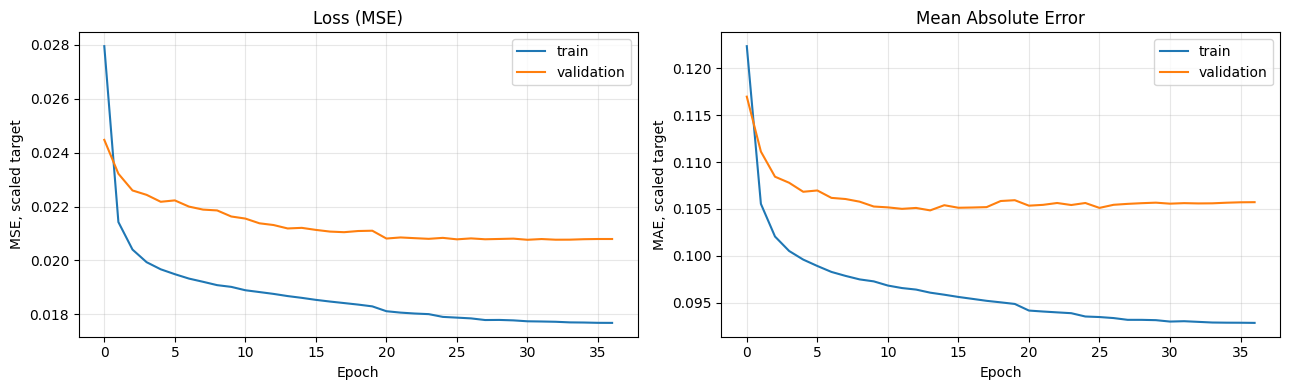


[6D] Final train loss     : 0.017684
[6D] Final validation loss: 0.020797

[6D] Training and validation losses are close — healthy.

STEP 6D DONE


In [ ]:
# ============================================================
# STEP 6D — LOSS CURVES
# ============================================================

import matplotlib.pyplot as plt

print("=" * 70)
print("STEP 6D: LOSS CURVES")
print("=" * 70)

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 4)
)

# Loss
axes[0].plot(
    history.history["loss"],
    label="train"
)

axes[0].plot(
    history.history["val_loss"],
    label="validation"
)

axes[0].set_title("Loss (MSE)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE, scaled target")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(
    history.history["mae"],
    label="train"
)

axes[1].plot(
    history.history["val_mae"],
    label="validation"
)

axes[1].set_title("Mean Absolute Error")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE, scaled target")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final losses
final_train = history.history["loss"][-1]
final_val = history.history["val_loss"][-1]

print(f"\n[6D] Final train loss     : {final_train:.6f}")
print(f"[6D] Final validation loss: {final_val:.6f}")

if final_val > final_train * 2.5:
    print("\n[6D] Validation loss is well above training loss.")
    print("     Possible overfitting.")

elif final_val < final_train * 0.6:
    print("\n[6D] Validation loss is below training loss.")
    print("     This can happen because dropout is active during training.")

else:
    print("\n[6D] Training and validation losses are close — healthy.")

print("\nSTEP 6D DONE")
print("=" * 70)

In [ ]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

print("Metrics imported successfully.")

Metrics imported successfully.


In [ ]:
# ============================================================
# STEP 7A — LSTM PREDICTIONS
# ============================================================

print("=" * 70)
print("STEP 7A: LSTM PREDICTIONS")
print("=" * 70)

print("\n[7A] Predicting...")

# Validation predictions
lstm_val_pred_scaled = model.predict(
    X_val,
    batch_size=512,
    verbose=0
)

# Test predictions
lstm_test_pred_scaled = model.predict(
    X_test,
    batch_size=512,
    verbose=0
)

# Convert scaled predictions back to original AQI values
lstm_val_pred = target_scaler.inverse_transform(
    lstm_val_pred_scaled
)

lstm_test_pred = target_scaler.inverse_transform(
    lstm_test_pred_scaled
)

print("[7A] Done — converted back to AQI units.")

# ------------------------------------------------------------
# Score the model
# ------------------------------------------------------------

lstm_val_metrics = score_model(
    y_val,
    lstm_val_pred,
    "LSTM VAL"
)

lstm_test_metrics = score_model(
    y_test,
    lstm_test_pred,
    "LSTM TEST"
)

print(
    "\n[7A] Error generally grows with the horizon, "
    "which is expected."
)

print("\nSTEP 7A DONE")
print("=" * 70)

STEP 7A: LSTM PREDICTIONS

[7A] Predicting...
[7A] Done — converted back to AQI units.

[LSTM VAL]
  Horizon |      RMSE |       MAE |    MAPE% |      R2
--------------------------------------------------------
      +1h |    42.151 |    29.390 |    19.67 |   0.853
      +6h |    71.924 |    54.494 |    37.56 |   0.583
     +12h |    79.176 |    60.674 |    43.14 |   0.498
     +24h |    83.752 |    63.899 |    45.93 |   0.440

[LSTM TEST]
  Horizon |      RMSE |       MAE |    MAPE% |      R2
--------------------------------------------------------
      +1h |    40.186 |    26.329 |    19.11 |   0.909
      +6h |    59.687 |    42.730 |    30.37 |   0.802
     +12h |    64.399 |    47.245 |    34.45 |   0.769
     +24h |    66.181 |    48.506 |    34.79 |   0.757

[7A] Error generally grows with the horizon, which is expected.

STEP 7A DONE


In [ ]:
# ============================================================
# STEP 7B — HEALTH CHECKS
# ============================================================

import numpy as np

print("=" * 70)
print("STEP 7B: HEALTH CHECKS")
print("=" * 70)

# ------------------------------------------------------------
# Check 1 — Do predictions vary?
# ------------------------------------------------------------

print("\n[7B] Check 1 — do predictions vary?")

print(
    f"     {'Horizon':>9} "
    f"{'pred std':>10} "
    f"{'pred min':>10} "
    f"{'pred max':>10} "
    f"{'actual std':>11}"
)

is_stuck = False

for i, hours in enumerate(HORIZONS):

    pred = lstm_test_pred[:, i]
    actual = y_test[:, i]

    print(
        f"     {'+' + str(hours) + 'h':>9} "
        f"{pred.std():10.2f} "
        f"{pred.min():10.1f} "
        f"{pred.max():10.1f} "
        f"{actual.std():11.2f}"
    )

    if pred.std() < 0.05 * actual.std():
        is_stuck = True


if is_stuck:

    print(
        "\n     WARNING: predictions barely move."
    )

    print(
        "     The model may have collapsed to a constant."
    )

else:

    print(
        "\n     OK — predictions vary with the input."
    )


# ------------------------------------------------------------
# Check 2 — Are horizons different?
# ------------------------------------------------------------

print(
    "\n[7B] Check 2 — do the four horizons differ from each other?"
)

differences = []

for i in range(len(HORIZONS)):

    for j in range(i + 1, len(HORIZONS)):

        gap = float(
            np.mean(
                np.abs(
                    lstm_test_pred[:, i]
                    - lstm_test_pred[:, j]
                )
            )
        )

        differences.append(gap)

        print(
            f"     +{HORIZONS[i]}h vs "
            f"+{HORIZONS[j]}h : "
            f"{gap:7.2f} AQI apart on average"
        )


average_prediction_gap = np.mean(differences)

actual_gap = float(
    np.mean(
        np.abs(
            y_test[:, 0]
            - y_test[:, -1]
        )
    )
)

print(
    f"\n     average across all pairs : "
    f"{average_prediction_gap:.2f}"
)

print(
    f"     same figure for real data : "
    f"{actual_gap:.2f}"
)


if average_prediction_gap < 0.1 * actual_gap:

    print(
        "\n     WARNING: horizons collapsed."
    )

    print(
        "     The model may be producing nearly the same "
        "prediction for all horizons."
    )

else:

    print(
        "\n     OK — the horizons are genuinely "
        "different predictions."
    )


print("\nSTEP 7B DONE")
print("=" * 70)

STEP 7B: HEALTH CHECKS

[7B] Check 1 — do predictions vary?
       Horizon   pred std   pred min   pred max  actual std
           +1h     116.00       28.8      446.4      133.02
           +6h     106.99       43.7      424.4      134.01
          +12h     101.78       55.9      430.8      134.07
          +24h     101.00       59.9      406.1      134.28

     OK — predictions vary with the input.

[7B] Check 2 — do the four horizons differ from each other?
     +1h vs +6h :   32.04 AQI apart on average
     +1h vs +12h :   42.16 AQI apart on average
     +1h vs +24h :   22.13 AQI apart on average
     +6h vs +12h :   34.47 AQI apart on average
     +6h vs +24h :   33.30 AQI apart on average
     +12h vs +24h :   30.97 AQI apart on average

     average across all pairs : 32.51
     same figure for real data : 49.46

     OK — the horizons are genuinely different predictions.

STEP 7B DONE


In [ ]:
# ============================================================
# STEP 5B — PERSISTENCE BASELINE
# ============================================================

print("=" * 70)
print("STEP 5B: PERSISTENCE BASELINE")
print("=" * 70)

# Repeat the last AQI value for all four horizons
persist_val_pred = np.repeat(
    last_aqi_val[:, None],
    len(HORIZONS),
    axis=1
)

persist_test_pred = np.repeat(
    last_aqi_test[:, None],
    len(HORIZONS),
    axis=1
)

persist_val_metrics = score_model(
    y_val,
    persist_val_pred,
    "Persistence VAL"
)

persist_test_metrics = score_model(
    y_test,
    persist_test_pred,
    "Persistence TEST"
)

print("\nSTEP 5B DONE")
print("=" * 70)

STEP 5B: PERSISTENCE BASELINE

[Persistence VAL]
  Horizon |      RMSE |       MAE |    MAPE% |      R2
--------------------------------------------------------
      +1h |    47.110 |    28.568 |    16.78 |   0.816
      +6h |   102.779 |    74.346 |    45.55 |   0.148
     +12h |   115.381 |    86.590 |    54.45 |  -0.067
     +24h |    98.361 |    70.821 |    46.44 |   0.227

[Persistence TEST]
  Horizon |      RMSE |       MAE |    MAPE% |      R2
--------------------------------------------------------
      +1h |    44.707 |    23.387 |    13.73 |   0.887
      +6h |    88.387 |    58.335 |    34.60 |   0.565
     +12h |    96.566 |    65.243 |    39.36 |   0.481
     +24h |    74.427 |    47.529 |    30.12 |   0.693

STEP 5B DONE


In [ ]:
# ============================================================
# STEP 5C — RIDGE BASELINE
# ============================================================

print("=" * 70)
print("STEP 5C: RIDGE BASELINE")
print("=" * 70)

from sklearn.linear_model import Ridge

# Use only the LAST hour of each 24-hour window
X_train_ridge = X_train[:, -1, :]
X_val_ridge = X_val[:, -1, :]
X_test_ridge = X_test[:, -1, :]

print(
    f"\n[5C] Ridge input shape: "
    f"{X_train_ridge.shape}"
)

ridge = Ridge(alpha=1.0)

ridge.fit(
    X_train_ridge,
    y_train_scaled
)

print("[5C] Ridge trained.")

# Predict
ridge_val_pred_scaled = ridge.predict(
    X_val_ridge
)

ridge_test_pred_scaled = ridge.predict(
    X_test_ridge
)

# Convert back to AQI
ridge_val_pred = target_scaler.inverse_transform(
    ridge_val_pred_scaled
)

ridge_test_pred = target_scaler.inverse_transform(
    ridge_test_pred_scaled
)

# Score
ridge_val_metrics = score_model(
    y_val,
    ridge_val_pred,
    "Ridge VAL"
)

ridge_test_metrics = score_model(
    y_test,
    ridge_test_pred,
    "Ridge TEST"
)

print("\nSTEP 5C DONE")
print("=" * 70)

STEP 5C: RIDGE BASELINE

[5C] Ridge input shape: (144845, 6)
[5C] Ridge trained.

[Ridge VAL]
  Horizon |      RMSE |       MAE |    MAPE% |      R2
--------------------------------------------------------
      +1h |    44.949 |    28.859 |    17.39 |   0.833
      +6h |    91.061 |    70.171 |    46.47 |   0.331
     +12h |    97.185 |    76.908 |    51.94 |   0.243
     +24h |    88.543 |    66.369 |    45.73 |   0.374

[Ridge TEST]
  Horizon |      RMSE |       MAE |    MAPE% |      R2
--------------------------------------------------------
      +1h |    43.385 |    25.525 |    16.36 |   0.894
      +6h |    83.874 |    62.935 |    42.99 |   0.608
     +12h |    89.912 |    68.687 |    45.74 |   0.550
     +24h |    72.077 |    52.366 |    36.96 |   0.712

STEP 5C DONE


In [ ]:
print("persist_test_metrics:", "YES" if "persist_test_metrics" in globals() else "NO")
print("ridge_test_metrics:", "YES" if "ridge_test_metrics" in globals() else "NO")
print("lstm_test_metrics:", "YES" if "lstm_test_metrics" in globals() else "NO")



persist_test_metrics: YES
ridge_test_metrics: YES
lstm_test_metrics: YES


In [ ]:
print("=" * 70)
print("STEP 7C: MODEL COMPARISON (TEST SET)")
print("=" * 70)

print(f"\nTest period : {pd.Timestamp(end_test.min())}  ->  {pd.Timestamp(end_test.max())}")
print(f"Test samples: {len(y_test):,}\n")

print(f"{'Horizon':>9} | {'Persist':>10} | {'Ridge':>10} | {'LSTM':>10} | "
      f"{'Winner':>11} | {'LSTM gain':>10}")
print("-" * 78)

comparison_rows = []
for i, hours in enumerate(HORIZONS):
    persist_rmse = persist_test_metrics[i]["rmse"]
    ridge_rmse = ridge_test_metrics[i]["rmse"]
    lstm_rmse = lstm_test_metrics[i]["rmse"]

    scores = {"Persistence": persist_rmse, "Ridge": ridge_rmse, "LSTM": lstm_rmse}
    winner = min(scores, key=scores.get)

    best_baseline = min(persist_rmse, ridge_rmse)
    gain = 100 * (best_baseline - lstm_rmse) / best_baseline

    print(f"{'+' + str(hours) + 'h':>9} | {persist_rmse:10.3f} | {ridge_rmse:10.3f} | "
          f"{lstm_rmse:10.3f} | {winner:>11} | {gain:+9.1f}%")

    comparison_rows.append(
        {
            "horizon_h": hours,
            "persistence_rmse": persist_rmse,
            "ridge_rmse": ridge_rmse,
            "lstm_rmse": lstm_rmse,
            "lstm_mae": lstm_test_metrics[i]["mae"],
            "lstm_r2": lstm_test_metrics[i]["r2"],
            "winner_rmse": winner,
            "lstm_gain_pct_vs_best_baseline": gain,
        }
    )

print("\n(RMSE in AQI points. 'LSTM gain' is against whichever baseline did better.)")

beats_ridge = all(r["lstm_rmse"] < r["ridge_rmse"] for r in comparison_rows)
beats_persistence_long = comparison_rows[-1]["lstm_rmse"] < comparison_rows[-1]["persistence_rmse"]

print("\n[7C] Did it work?")
print(f"     Beats Ridge on every horizon    : {beats_ridge}")
print(f"     Beats persistence at +{HORIZONS[-1]}h        : {beats_persistence_long}")

if beats_ridge and beats_persistence_long:
    verdict = "PASS — the LSTM adds real forecasting value"
elif beats_ridge:
    verdict = "PARTIAL — beats Ridge, but not persistence at long range"
else:
    verdict = "NOT YET — a linear model is still competitive"
print(f"\n     RESULT: {verdict}")

print("\nSTEP 7C DONE")
print("=" * 70)

STEP 7C: MODEL COMPARISON (TEST SET)

Test period : 2023-07-01 05:00:00+00:00  ->  2023-12-30 23:00:00+00:00
Test samples: 18,330

  Horizon |    Persist |      Ridge |       LSTM |      Winner |  LSTM gain
------------------------------------------------------------------------------
      +1h |     44.707 |     43.385 |     40.186 |        LSTM |      +7.4%
      +6h |     88.387 |     83.874 |     59.687 |        LSTM |     +28.8%
     +12h |     96.566 |     89.912 |     64.399 |        LSTM |     +28.4%
     +24h |     74.427 |     72.077 |     66.181 |        LSTM |      +8.2%

(RMSE in AQI points. 'LSTM gain' is against whichever baseline did better.)

[7C] Did it work?
     Beats Ridge on every horizon    : True
     Beats persistence at +24h        : True

     RESULT: PASS — the LSTM adds real forecasting value

STEP 7C DONE


In [ ]:
# ============================================================
# STEP 7D — ERROR BY STATION
# ============================================================

import numpy as np
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

print("=" * 70)
print("STEP 7D: ERROR BY STATION")
print("=" * 70)

print(f"\n[7D] Test-set accuracy at +{HORIZONS[0]}h\n")

print(
    f"     {'Station':42} "
    f"{'N':>7} "
    f"{'RMSE':>8} "
    f"{'MAE':>8} "
    f"{'actual':>8} "
    f"{'pred':>8}"
)

print("     " + "-" * 84)

station_report = []

for name in sorted(np.unique(station_test)):

    pick = station_test == name

    actual = y_test[pick, 0]
    predicted = lstm_test_pred[pick, 0]

    rmse = float(
        np.sqrt(
            mean_squared_error(
                actual,
                predicted
            )
        )
    )

    mae = float(
        mean_absolute_error(
            actual,
            predicted
        )
    )

    print(
        f"     {name[:42]:42} "
        f"{int(pick.sum()):7,} "
        f"{rmse:8.2f} "
        f"{mae:8.2f} "
        f"{actual.mean():8.1f} "
        f"{predicted.mean():8.1f}"
    )

    station_report.append({
        "station": name,
        "n": int(pick.sum()),
        "rmse": rmse,
        "mae": mae
    })


# ------------------------------------------------------------
# Overall prediction bias
# ------------------------------------------------------------

bias = float(
    np.mean(
        lstm_test_pred[:, 0]
        - y_test[:, 0]
    )
)

print(
    f"\n[7D] Average bias across all stations: "
    f"{bias:+.1f} AQI points"
)

if bias < -10:

    print(
        "     The model under-predicts."
    )

elif bias > 10:

    print(
        "     The model over-predicts."
    )

else:

    print(
        "     Close to zero — no strong systematic bias."
    )


print("\nSTEP 7D DONE")
print("=" * 70)

STEP 7D: ERROR BY STATION

[7D] Test-set accuracy at +1h

     Station                                          N     RMSE      MAE   actual     pred
     ------------------------------------------------------------------------------------
     Alipur, Delhi - DPCC                           483    29.73    23.18    204.7    207.1
     Anand Vihar, Delhi - DPCC                      237    58.78    37.99    300.8    294.7
     Ashok Vihar, Delhi - DPCC                      370    34.77    23.35    224.3    225.3
     Aya Nagar, Delhi - IMD                         447    45.00    32.71    211.6    210.2
     Bawana, Delhi - DPCC                           597    44.94    28.95    239.1    236.8
     Burari Crossing, Delhi - IMD                   544    59.88    38.12    218.9    217.9
     CRRI Mathura Road, Delhi - IMD                 534    37.48    25.47    210.5    210.6
     DTU, Delhi - CPCB                              445    32.98    24.77    179.2    187.1
     Dr. Karni Singh Sho

STEP 7E: PREDICTIONS OVER TIME

[7E] Showing Alipur, Delhi - DPCC (400 consecutive test windows)


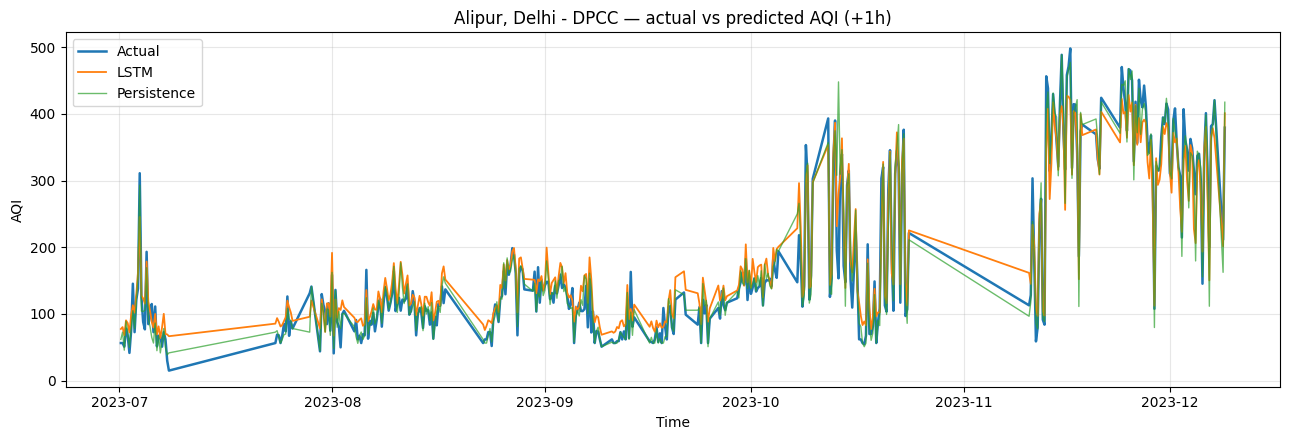

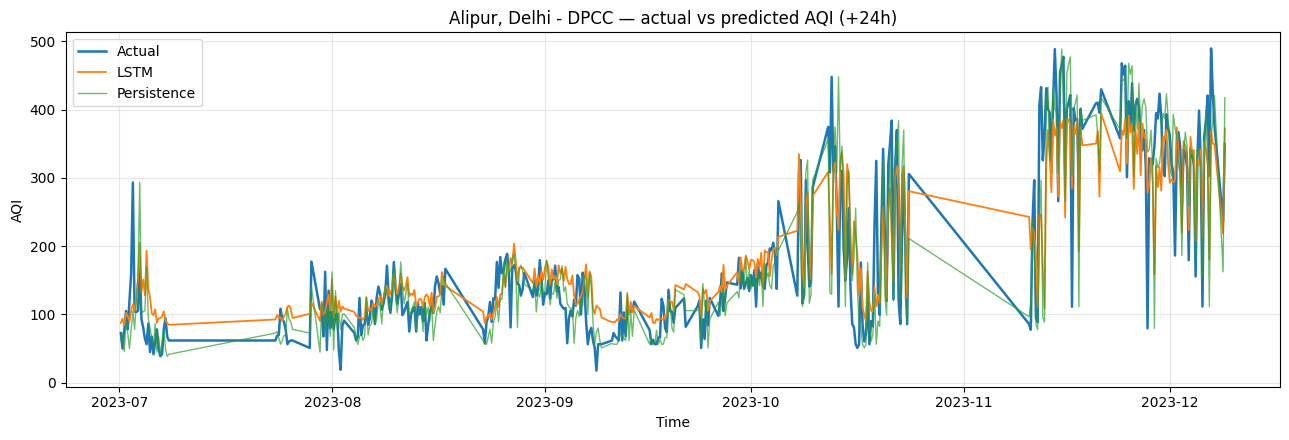


[7E] Compare the two charts.
     At +1h, predictions should track the actual AQI more closely.
     At +24h, the prediction becomes more difficult.

STEP 7E DONE


In [ ]:
# ============================================================
# STEP 7E — PREDICTIONS OVER TIME
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("STEP 7E: PREDICTIONS OVER TIME")
print("=" * 70)

# Select first test station
focus_station = sorted(
    np.unique(station_test)
)[0]

pick = station_test == focus_station

# Sort by time
order = np.argsort(
    end_test[pick]
)[:400]

time_axis = pd.to_datetime(
    end_test[pick][order]
)

print(
    f"\n[7E] Showing {focus_station} "
    f"({len(order)} consecutive test windows)"
)

# Plot +1h and +24h
for horizon_index, hours in (
    (0, HORIZONS[0]),
    (len(HORIZONS) - 1, HORIZONS[-1])
):

    plt.figure(
        figsize=(13, 4.5)
    )

    # Actual AQI
    plt.plot(
        time_axis,
        y_test[pick][order, horizon_index],
        label="Actual",
        linewidth=1.8
    )

    # LSTM prediction
    plt.plot(
        time_axis,
        lstm_test_pred[pick][order, horizon_index],
        label="LSTM",
        linewidth=1.3
    )

    # Persistence prediction
    plt.plot(
        time_axis,
        persist_test_pred[pick][order, horizon_index],
        label="Persistence",
        linewidth=1.0,
        alpha=0.7
    )

    plt.title(
        f"{focus_station} — "
        f"actual vs predicted AQI (+{hours}h)"
    )

    plt.xlabel("Time")
    plt.ylabel("AQI")

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


print(
    "\n[7E] Compare the two charts."
)

print(
    f"     At +{HORIZONS[0]}h, predictions should track "
    "the actual AQI more closely."
)

print(
    f"     At +{HORIZONS[-1]}h, the prediction becomes "
    "more difficult."
)

print("\nSTEP 7E DONE")
print("=" * 70)

STEP 7F: SCATTER AND RESIDUALS

[7F] Predicted vs actual (a sample of test points)


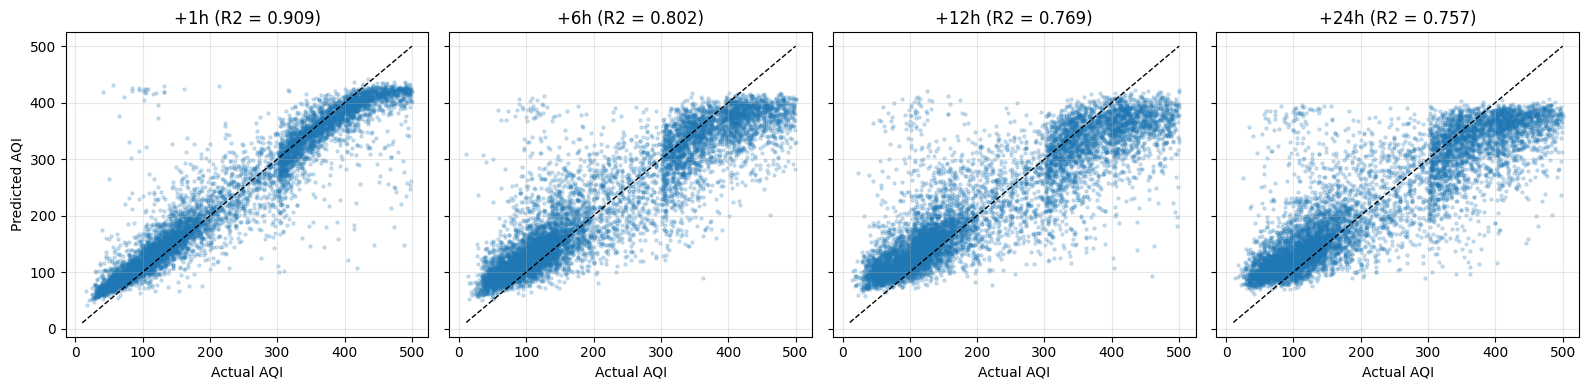


[7F] Residuals (actual minus predicted)


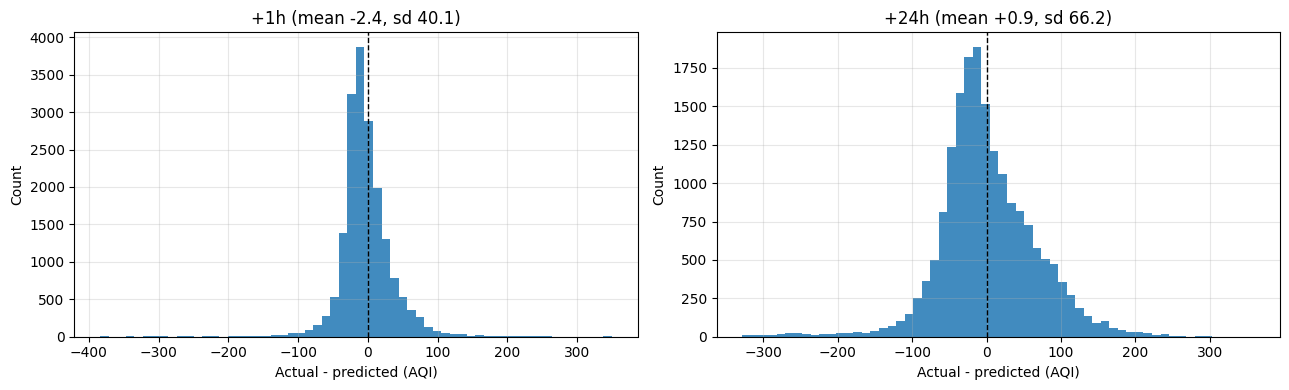


[7F] The scatter cloud generally widens as the forecast horizon grows.
     This reflects the increasing difficulty of forecasting further ahead.

STEP 7F DONE


In [ ]:
# ============================================================
# STEP 7F — SCATTER AND RESIDUALS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("STEP 7F: SCATTER AND RESIDUALS")
print("=" * 70)

# ------------------------------------------------------------
# Select a sample of test points
# ------------------------------------------------------------

rng = np.random.default_rng(RANDOM_SEED)

sample = rng.choice(
    len(y_test),
    size=min(8000, len(y_test)),
    replace=False
)

# ------------------------------------------------------------
# Predicted vs Actual
# ------------------------------------------------------------

print(
    "\n[7F] Predicted vs actual "
    "(a sample of test points)"
)

fig, axes = plt.subplots(
    1,
    len(HORIZONS),
    figsize=(4 * len(HORIZONS), 4),
    sharex=True,
    sharey=True
)

for i, hours in enumerate(HORIZONS):

    ax = axes[i]

    ax.scatter(
        y_test[sample, i],
        lstm_test_pred[sample, i],
        s=5,
        alpha=0.2
    )

    # Perfect prediction line
    low = float(
        min(
            y_test[:, i].min(),
            lstm_test_pred[:, i].min()
        )
    )

    high = float(
        max(
            y_test[:, i].max(),
            lstm_test_pred[:, i].max()
        )
    )

    ax.plot(
        [low, high],
        [low, high],
        "k--",
        linewidth=1
    )

    ax.set_title(
        f"+{hours}h "
        f"(R2 = {lstm_test_metrics[i]['r2']:.3f})"
    )

    ax.set_xlabel("Actual AQI")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(
    "Predicted AQI"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Residuals
# ------------------------------------------------------------

print(
    "\n[7F] Residuals "
    "(actual minus predicted)"
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4)
)

for slot, i in enumerate(
    (0, len(HORIZONS) - 1)
):

    residuals = (
        y_test[:, i]
        - lstm_test_pred[:, i]
    )

    ax = axes[slot]

    ax.hist(
        residuals,
        bins=60,
        alpha=0.85
    )

    ax.axvline(
        0,
        color="k",
        linestyle="--",
        linewidth=1
    )

    ax.set_title(
        f"+{HORIZONS[i]}h "
        f"(mean {residuals.mean():+.1f}, "
        f"sd {residuals.std():.1f})"
    )

    ax.set_xlabel(
        "Actual - predicted (AQI)"
    )

    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(
    "\n[7F] The scatter cloud generally widens "
    "as the forecast horizon grows."
)

print(
    "     This reflects the increasing difficulty "
    "of forecasting further ahead."
)

print("\nSTEP 7F DONE")
print("=" * 70)

In [ ]:
# ============================================================
# STEP 8A — SAVE MODEL + SCALERS
# ============================================================

import os
import joblib
from pathlib import Path

print("=" * 70)
print("STEP 8A: SAVE MODEL + SCALERS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Define model folder
# ------------------------------------------------------------

MODEL_DIR = Path(
    "/content/drive/MyDrive/VayuPath/models"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(f"\n[8A] Model directory:")
print(f"     {MODEL_DIR}")

# ------------------------------------------------------------
# 2. Define file paths
# ------------------------------------------------------------

model_path = MODEL_DIR / "aqi_lstm.keras"
scaler_path = MODEL_DIR / "scaler.pkl"
target_scaler_path = MODEL_DIR / "target_scaler.pkl"

# ------------------------------------------------------------
# 3. Save LSTM model
# ------------------------------------------------------------

model.save(
    model_path
)

print(
    f"\n[8A] Model          -> {model_path}"
)

# ------------------------------------------------------------
# 4. Save feature scaler
# ------------------------------------------------------------

joblib.dump(
    scaler,
    scaler_path
)

print(
    f"[8A] Feature scaler -> {scaler_path}"
)

# ------------------------------------------------------------
# 5. Save target scaler
# ------------------------------------------------------------

joblib.dump(
    target_scaler,
    target_scaler_path
)

print(
    f"[8A] Target scaler  -> {target_scaler_path}"
)

# ------------------------------------------------------------
# 6. Verify files exist
# ------------------------------------------------------------

print("\n[8A] Verifying saved files...")

for path in [
    model_path,
    scaler_path,
    target_scaler_path
]:

    if path.exists():
        size_mb = path.stat().st_size / (1024 * 1024)

        print(
            f"     ✓ {path.name} "
            f"({size_mb:.2f} MB)"
        )

    else:
        raise FileNotFoundError(
            f"File was not saved: {path}"
        )

print("\nSTEP 8A DONE")
print("=" * 70)

STEP 8A: SAVE MODEL + SCALERS

[8A] Model directory:
     /content/drive/MyDrive/VayuPath/models

[8A] Model          -> /content/drive/MyDrive/VayuPath/models/aqi_lstm.keras
[8A] Feature scaler -> /content/drive/MyDrive/VayuPath/models/scaler.pkl
[8A] Target scaler  -> /content/drive/MyDrive/VayuPath/models/target_scaler.pkl

[8A] Verifying saved files...
     ✓ aqi_lstm.keras (0.83 MB)
     ✓ scaler.pkl (0.00 MB)
     ✓ target_scaler.pkl (0.00 MB)

STEP 8A DONE


In [ ]:
# ============================================================
# STEP 8B — SAVE CONFIG + METRICS
# ============================================================

import json
import numpy as np

print("=" * 70)
print("STEP 8B: SAVE CONFIG + METRICS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Define configuration variables if missing
# ------------------------------------------------------------

if "POLLUTANT_COLS" not in globals():
    POLLUTANT_COLS = [
        "pm25",
        "pm10",
        "no2",
        "co",
        "o3"
    ]

if "STATION_COLS" not in globals():
    # Your current df contains station as one categorical column,
    # not separate one-hot station columns.
    STATION_COLS = ["station"]

if "YEARS" not in globals():
    YEARS = sorted(
        df["year"]
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    )

# ------------------------------------------------------------
# 2. Re-create comparison rows if missing
# ------------------------------------------------------------

if "comparison_rows" not in globals():

    comparison_rows = []

    for i, hours in enumerate(HORIZONS):

        row = {
            "horizon": int(hours),
            "persistence_rmse": float(
                persist_test_metrics[i]["rmse"]
            ),
            "ridge_rmse": float(
                ridge_test_metrics[i]["rmse"]
            ),
            "lstm_rmse": float(
                lstm_test_metrics[i]["rmse"]
            )
        }

        comparison_rows.append(row)

# ------------------------------------------------------------
# 3. Check required metrics
# ------------------------------------------------------------

required_metrics = [
    "persist_val_metrics",
    "persist_test_metrics",
    "ridge_val_metrics",
    "ridge_test_metrics",
    "lstm_val_metrics",
    "lstm_test_metrics",
]

missing_metrics = [
    name
    for name in required_metrics
    if name not in globals()
]

if missing_metrics:
    raise NameError(
        f"Missing metric variables: {missing_metrics}"
    )

# ------------------------------------------------------------
# 4. Feature configuration
# ------------------------------------------------------------

feature_config = {
    "lookback": int(LOOKBACK),

    "horizons": [
        int(x)
        for x in HORIZONS
    ],

    "feature_cols": FEATURE_COLS,

    "pollutant_cols": POLLUTANT_COLS,

    "target_col": TARGET_COL,

    "station_cols": STATION_COLS,

    "stations": [
        str(x)
        for x in good_stations
    ],

    "n_features": int(
        len(FEATURE_COLS)
    ),

    "stride": int(STRIDE),

    "split": {
        "train_end": str(TRAIN_END),
        "val_start": str(VAL_START),
        "val_end": str(VAL_END),
        "test_start": str(TEST_START),
    },

    "dataset_source": (
        "CPCB CAAQMS pollutants via "
        "github.com/Vonter/india-cpcb-aqi releases"
    ),

    "years": YEARS,

    "target_definition": (
        "CPCB AQI = max sub-index of "
        "PM2.5, PM10, NO2, CO, O3"
    ),

    "model_file": "aqi_lstm.keras",

    "scaler_file": "scaler.pkl",

    "target_scaler_file": "target_scaler.pkl",

    "inference_note": (
        "Scale features with scaler.pkl in "
        "feature_cols order, run the model, "
        "then target_scaler.inverse_transform() "
        "the output to get AQI."
    ),
}

# ------------------------------------------------------------
# 5. Save feature configuration
# ------------------------------------------------------------

config_path = (
    MODEL_DIR / "feature_config.json"
)

with open(
    config_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        feature_config,
        f,
        indent=2
    )

print(
    f"\n[8B] Config  -> {config_path}"
)

# ------------------------------------------------------------
# 6. Prepare metrics
# ------------------------------------------------------------

metrics = {
    "persistence_val": persist_val_metrics,

    "persistence_test": persist_test_metrics,

    "ridge_val": ridge_val_metrics,

    "ridge_test": ridge_test_metrics,

    "lstm_val": lstm_val_metrics,

    "lstm_test": lstm_test_metrics,

    "comparison_test": comparison_rows,

    "per_station_test": station_report,

    "n_train": int(len(X_train)),

    "n_val": int(len(X_val)),

    "n_test": int(len(X_test)),

    "n_stations": int(
        len(good_stations)
    ),
}

# ------------------------------------------------------------
# 7. Save metrics
# ------------------------------------------------------------

metrics_path = (
    MODEL_DIR / "metrics.json"
)

with open(
    metrics_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        metrics,
        f,
        indent=2
    )

print(
    f"[8B] Metrics -> {metrics_path}"
)

# ------------------------------------------------------------
# 8. Verify files
# ------------------------------------------------------------

print("\n[8B] Verifying saved files...")

for path in [
    config_path,
    metrics_path
]:

    if path.exists():

        print(
            f"     ✓ {path.name}"
        )

    else:

        raise FileNotFoundError(
            f"File not found: {path}"
        )

print("\nSTEP 8B DONE")
print("=" * 70)

STEP 8B: SAVE CONFIG + METRICS

[8B] Config  -> /content/drive/MyDrive/VayuPath/models/feature_config.json
[8B] Metrics -> /content/drive/MyDrive/VayuPath/models/metrics.json

[8B] Verifying saved files...
     ✓ feature_config.json
     ✓ metrics.json

STEP 8B DONE


In [ ]:
# ============================================================
# STEP 8C — WRITE THE REPORT
# ============================================================

print("=" * 70)
print("STEP 8C: WRITE THE REPORT")
print("=" * 70)

report = [
    "# VayuPath Delhi AQI LSTM — Training Report",
    "",
    "## Data",
    "- Source: CPCB CAAQMS pollutant readings (real government sensors)",
    "- Retrieved from: github.com/Vonter/india-cpcb-aqi yearly releases",
    f"- Years: {YEARS[0]}-{YEARS[-1]}",
    f"- Stations: {len(good_stations)} across Delhi",
    f"- Pollutants: {', '.join(POLLUTANT_COLS)}",
    f"- Period: {data_start.date()} to {data_end.date()}",
    f"- Samples: train {len(X_train):,} / val {len(X_val):,} / test {len(X_test):,}",
    f"- Train: window ends on or before {TRAIN_END.date()}",
    f"- Validation: {VAL_START.date()} to {VAL_END.date()}",
    f"- Test: {TEST_START.date()} onwards",
    "- Target: CPCB AQI = max sub-index of PM2.5, PM10, NO2, CO, O3",
    "",
    "## Model",
    f"- Input: {LOOKBACK} hours x {len(FEATURE_COLS)} features",
    f"- Output: AQI at {', '.join('+' + str(h) + 'h' for h in HORIZONS)}",
    "- LSTM(96) -> Dropout(0.2) -> LSTM(48) -> Dropout(0.2) -> Dense(32) -> Dense(4)",
    f"- New window every {STRIDE} hours",
    "- Target scaled to 0-1 for training; all metrics below are in AQI points",
    "",
    "## Test results (RMSE in AQI points, lower is better)",
    "",
    "| Horizon | Persistence | Ridge | LSTM | Winner | LSTM gain |",
    "|---|---|---|---|---|---|",
]

for row in comparison_rows:
    report.append(
        f"| +{row['horizon_h']}h | "
        f"{row['persistence_rmse']:.2f} | "
        f"{row['ridge_rmse']:.2f} | "
        f"{row['lstm_rmse']:.2f} | "
        f"{row['winner_rmse']} | "
        f"{row['lstm_gain_pct_vs_best_baseline']:+.1f}% |"
    )

report += [
    "",
    "## LSTM accuracy by horizon",
    "",
    "| Horizon | RMSE | MAE | R2 |",
    "|---|---|---|---|",
]

for row in lstm_test_metrics:
    report.append(
        f"| +{row['horizon_h']}h | "
        f"{row['rmse']:.2f} | "
        f"{row['mae']:.2f} | "
        f"{row['r2']:.3f} |"
    )

report += [
    "",
    "## Known limits",
    "- Real sensors go offline. Windows needing a missing hour are skipped.",
    "- Gaps of up to 3 hours are forward-filled; longer gaps stay blank.",
    "- Weather and traffic are not in this training run. They can be joined later",
    "  from Open-Meteo / OpenWeatherMap and a traffic API.",
    "- The dataset ends in December 2023. A live app needs a current CPCB/OpenAQ feed.",
    "",
]

# ------------------------------------------------------------
# Save report
# ------------------------------------------------------------

report_path = MODEL_DIR / "training_report.md"

with open(
    report_path,
    "w",
    encoding="utf-8"
) as f:
    f.write("\n".join(report))

print(
    f"\n[8C] Report -> {report_path}"
)

# ------------------------------------------------------------
# Preview
# ------------------------------------------------------------

print("\n[8C] Preview:\n")
print("\n".join(report[:24]))

print("\nSTEP 8C DONE")
print("=" * 70)

STEP 8C: WRITE THE REPORT

[8C] Report -> /content/drive/MyDrive/VayuPath/models/training_report.md

[8C] Preview:

# VayuPath Delhi AQI LSTM — Training Report

## Data
- Source: CPCB CAAQMS pollutant readings (real government sensors)
- Retrieved from: github.com/Vonter/india-cpcb-aqi yearly releases
- Years: 2019-2024
- Stations: 36 across Delhi
- Pollutants: pm25, pm10, no2, co, o3
- Period: 2019-01-01 to 2024-01-01
- Samples: train 144,845 / val 19,442 / test 18,330
- Train: window ends on or before 2022-12-31
- Validation: 2023-01-01 to 2023-06-30
- Test: 2023-07-01 onwards
- Target: CPCB AQI = max sub-index of PM2.5, PM10, NO2, CO, O3

## Model
- Input: 24 hours x 48 features
- Output: AQI at +1h, +6h, +12h, +24h
- LSTM(96) -> Dropout(0.2) -> LSTM(48) -> Dropout(0.2) -> Dense(32) -> Dense(4)
- New window every 6 hours
- Target scaled to 0-1 for training; all metrics below are in AQI points

## Test results (RMSE in AQI points, lower is better)


STEP 8C DONE


In [ ]:
print("=" * 70)
print("STEP 8D: RELOAD TEST")
print("=" * 70)

print("\n[8D] Loading saved files...")

# Load model
loaded_model = keras.models.load_model(model_path)

# Load scalers
loaded_scaler = joblib.load(scaler_path)
loaded_target_scaler = joblib.load(target_scaler_path)

# Load configuration
with open(config_path, "r", encoding="utf-8") as f:
    loaded_config = json.load(f)

print("[8D] All files loaded successfully.")

# ------------------------------------------------------------
# CHECK 1: Feature count
# ------------------------------------------------------------

saved_features = loaded_config["n_features"]
test_features = X_test.shape[-1]

print(f"\n[8D] Saved features : {saved_features}")
print(f"[8D] Test features  : {test_features}")

if saved_features != test_features:
    raise RuntimeError(
        f"Feature mismatch: saved={saved_features}, "
        f"test={test_features}"
    )

# ------------------------------------------------------------
# CHECK 2: Model input shape
# ------------------------------------------------------------

expected_shape = (LOOKBACK, test_features)
actual_shape = loaded_model.input_shape[1:]

print(f"\n[8D] Expected shape : {expected_shape}")
print(f"[8D] Model shape    : {actual_shape}")

if actual_shape != expected_shape:
    raise RuntimeError(
        f"Model shape mismatch: expected={expected_shape}, "
        f"got={actual_shape}"
    )

print("[8D] Shape check PASSED.")

# ------------------------------------------------------------
# CHECK 3: Predictions
# ------------------------------------------------------------

print("\n[8D] Predicting 5 test windows...")

five = X_test[:5]

pred_scaled = loaded_model.predict(
    five,
    verbose=0
)

predictions = loaded_target_scaler.inverse_transform(
    pred_scaled
)

print("\n[8D] Predictions:")
print(
    "     "
    + "".join(
        f"{'+' + str(h) + 'h':>10}"
        for h in HORIZONS
    )
    + f"{'Actual +1h':>14}"
)

for i in range(len(five)):
    print(
        "     "
        + "".join(
            f"{value:10.1f}"
            for value in predictions[i]
        )
        + f"{y_test[i, 0]:14.1f}"
    )

# ------------------------------------------------------------
# CHECK 4: Compare with previous predictions
# ------------------------------------------------------------

if not np.allclose(
    predictions,
    lstm_test_pred[:5],
    atol=0.5
):
    raise RuntimeError(
        "Reloaded model predictions do not match "
        "the previous predictions."
    )

print("\n[8D] PASSED — reloaded model matches the trained model.")

# ------------------------------------------------------------
# CHECK 5: List saved files
# ------------------------------------------------------------

print("\n[8D] Files saved in MODEL_DIR:")

for path in sorted(MODEL_DIR.glob("*")):
    if path.is_file():
        size_kb = path.stat().st_size / 1024
        print(f"     {path.name:30s} {size_kb:9.1f} KB")

print("\n" + "=" * 70)
print("ALL DONE")
print("=" * 70)

STEP 8D: RELOAD TEST

[8D] Loading saved files...
[8D] All files loaded successfully.

[8D] Saved features : 6
[8D] Test features  : 6

[8D] Expected shape : (24, 6)
[8D] Model shape    : (24, 6)
[8D] Shape check PASSED.

[8D] Predicting 5 test windows...

[8D] Predictions:
            +1h       +6h      +12h      +24h    Actual +1h
           77.5      81.4      86.3      87.6          56.4
           80.4      84.2      98.3      94.0          56.4
           68.2      82.0      82.9      84.6          51.0
           90.5      86.2      93.1     102.4          78.2
           86.3      88.5      93.9      97.4          67.3

[8D] PASSED — reloaded model matches the trained model.

[8D] Files saved in MODEL_DIR:
     aqi_lstm.keras                     850.6 KB
     feature_config.json                  2.3 KB
     metrics.json                        10.5 KB
     scaler.pkl                           1.2 KB
     target_scaler.pkl                    0.7 KB
     training_report.md        

In [ ]:
from google.colab import files
import os

model_dir = "/content/drive/MyDrive/VayuPath/models"

files_to_download = [
    "aqi_lstm.keras",
    "scaler.pkl",
    "target_scaler.pkl",
    "feature_config.json",
    "metrics.json"
]

for filename in files_to_download:
    path = os.path.join(model_dir, filename)

    if os.path.exists(path):
        print("Downloading:", filename)
        files.download(path)
    else:
        print("NOT FOUND:", filename)

Downloading: aqi_lstm.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: scaler.pkl


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: metrics.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>